## GROUP 17-DESIGN AND IMPLEMENTATION OF A SMART FOOD SUPPLY CHAIN MANAGEMENT SYSTEM FOR RESTAURANTS IN MAKERERE UNIVERSITY 
 Food Restaurants and kiosks within Makerere University serve a large population whose consuption patterns shift significantly with academic timetables, examination periods, and time of day.

 We as group 17 synthetically created datasets based on the above variations and we created two datasets
 1) Makerere_Cafeteria_synthetic.csv
 2) Makerere_kiosk_synthetic.csv

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import random
from datetime import date, timedelta, datetime


### Makerere Cafeteria Synthetic Data Agent

 It generates realistic synthetic data that is produced by the Cafeterias within Makere University

Columns produced:
  Date, Day_of_Week, Academic_Period, Is_Weekend, Meal,
  Portions_Prepared, Portions_Sold, Waste_Portions, Waste_Pct,
  Price_UGX, Revenue_UGX, Ingredient_Cost_UGX, Waste_Cost_UGX,
  Gross_Profit_UGX,
  Posho_Flour_kg, Beans_kg, Cooking_Oil_L, Matooke_kg, Groundnuts_kg,
  Rice_kg, Chicken_kg, Offal_kg, Onions_kg, Irish_Potatoes_kg,
  Eggs_units, Wheat_Flour_kg, Cabbage_kg, Tomatoes_kg


In [47]:

MEAL_CONFIG = {
    "Posho & Beans": {
        "price": 3000,
        "base_demand_mean": 188,          
        "base_demand_std": 139,
        "waste_pct_mean": 12.8,
        "waste_pct_std": 5.8,
        "cogs_ratio": 0.467,  # ingredient cost / revenue
        "ingredients_per_portion": {     
            "Posho_Flour_kg":  0.25,
            "Beans_kg":        0.15,
            "Cooking_Oil_L":   0.02,
        },
    },
    "Matooke & Groundnut Stew": {
        "price": 4000,
        "base_demand_mean": 149,
        "base_demand_std": 110,
        "waste_pct_mean": 12.5,
        "waste_pct_std": 5.5,
        "cogs_ratio": 0.558,
        "ingredients_per_portion": {
            "Matooke_kg":    0.40,
            "Groundnuts_kg": 0.10,
            "Cooking_Oil_L": 0.03,
        },
    },
    "Rice & Chicken": {
        "price": 6000,
        "base_demand_mean": 118,
        "base_demand_std": 87,
        "waste_pct_mean": 13.2,
        "waste_pct_std": 5.8,
        "cogs_ratio": 0.684,
        "ingredients_per_portion": {
            "Rice_kg":       0.20,
            "Chicken_kg":    0.18,
            "Cooking_Oil_L": 0.04,
        },
    },
    "Katogo (Offal+Matoke)": {
        "price": 3500,
        "base_demand_mean": 96,
        "base_demand_std": 71,
        "waste_pct_mean": 13.8,
        "waste_pct_std": 6.4,
        "cogs_ratio": 0.504,
        "ingredients_per_portion": {
            "Matooke_kg":  0.35,
            "Offal_kg":    0.15,
            "Onions_kg":   0.05,
        },
    },
    "Chips & Eggs": {
        "price": 4500,
        "base_demand_mean": 107,
        "base_demand_std": 79,
        "waste_pct_mean": 12.9,
        "waste_pct_std": 6.1,
        "cogs_ratio": 0.520,
        "ingredients_per_portion": {
            "Irish_Potatoes_kg": 0.30,
            "Eggs_units":        1.50,
            "Cooking_Oil_L":     0.05,
        },
    },
    "Rolex": {
        "price": 2500,
        "base_demand_mean": 215,
        "base_demand_std": 159,
        "waste_pct_mean": 12.5,
        "waste_pct_std": 5.9,
        "cogs_ratio": 0.430,
        "ingredients_per_portion": {
            "Eggs_units":      1.00,
            "Wheat_Flour_kg":  0.10,
            "Cabbage_kg":      0.05,
            "Tomatoes_kg":     0.04,
        },
    },
}

# All meals served every day 
ALL_MEALS = list(MEAL_CONFIG.keys())

# Academic calendar mapping: period label → demand multiplier
ACADEMIC_PERIODS = {
    "Sem1_Teaching": 1.10,
    "Sem1_Exams":    1.30,
    "Sem_Break":     0.45,
    "Sem2_Teaching": 1.05,
    "Sem2_Exams":    1.25,
    "Xmas_Break":    0.35,
    "Other":         0.80,
}

DAY_NAMES = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]


#  Academic calendar builder

def get_academic_period(d: date) -> str:
    """Return the academic period label for a given date (rough Makerere schedule)."""
    m, day = d.month, d.day
    if (m == 2) or (m == 3) or (m == 4 and day <= 15):
        return "Sem1_Teaching"
    if (m == 4 and day > 15) or (m == 5 and day <= 15):
        return "Sem1_Exams"
    if (m == 5 and day > 15) or m == 6 or (m == 7 and day <= 15):
        return "Sem_Break"
    if (m == 7 and day > 15) or m == 8 or (m == 9) or (m == 10 and day <= 15):
        return "Sem2_Teaching"
    if (m == 10 and day > 15) or (m == 11 and day <= 15):
        return "Sem2_Exams"
    if (m == 11 and day > 15) or m == 12 or m == 1:
        return "Xmas_Break"
    return "Other"


#  CafeteriaAgent

class CafeteriaAgent:
    """
    Simulates one Makerere cafeteria for a given date range and produces a
    row-per-meal-per-day DataFrame that matches the real dataset's columns.
    """

    def __init__(self, cafeteria_id: int = 1, seed: int | None = None):
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)

        self.cafeteria_id = cafeteria_id

        # Slight per-cafeteria personality noise
        self.demand_noise   = round(random.uniform(0.85, 1.15), 3)
        self.waste_noise    = round(random.uniform(0.90, 1.10), 3)
        self.quality_factor = round(random.uniform(0.95, 1.05), 3)

    #  Internal helpers 
    def _demand_multiplier(self, academic_period: str, is_weekend: bool) -> float:
        mult = ACADEMIC_PERIODS.get(academic_period, 0.80)
        if is_weekend:
            mult *= 0.55           # much quieter on weekends
        mult *= self.demand_noise
        return max(mult, 0.05)

    def _portions_prepared(self, meal: str, mult: float) -> int:
        cfg = MEAL_CONFIG[meal]
        raw = np.random.normal(cfg["base_demand_mean"] * mult,
                               cfg["base_demand_std"] * 0.35)
        return max(int(round(raw)), 5)

    def _waste_pct(self, meal: str) -> float:
        cfg = MEAL_CONFIG[meal]
        raw = np.random.normal(cfg["waste_pct_mean"] * self.waste_noise,
                               cfg["waste_pct_std"])
        return round(np.clip(raw, 1.0, 40.0), 1)

    def _ingredients(self, meal: str, portions: int) -> dict:
        recipe = MEAL_CONFIG[meal]["ingredients_per_portion"]
        row = {col: 0.0 for col in [
            "Posho_Flour_kg", "Beans_kg", "Cooking_Oil_L", "Matooke_kg",
            "Groundnuts_kg", "Rice_kg", "Chicken_kg", "Offal_kg",
            "Onions_kg", "Irish_Potatoes_kg", "Eggs_units",
            "Wheat_Flour_kg", "Cabbage_kg", "Tomatoes_kg",
        ]}
        for ing, per_portion in recipe.items():
            # Small day-to-day noise (±5 %)
            noise = random.uniform(0.95, 1.05)
            row[ing] = round(per_portion * portions * noise, 1)
        return row

    # Core simulation 

    def simulate_day(self, sim_date: date) -> list[dict]:
        """Returns a list of row dicts — one per meal — for this date."""
        dow_idx    = sim_date.weekday()          # 0 = Monday … 6 = Sunday
        day_name   = DAY_NAMES[dow_idx]
        is_weekend = dow_idx >= 5
        acad       = get_academic_period(sim_date)
        mult       = self._demand_multiplier(acad, is_weekend)

        rows = []
        for meal in ALL_MEALS:
            cfg = MEAL_CONFIG[meal]

            # --- Volume ---
            portions_prepared = self._portions_prepared(meal, mult)
            waste_pct         = self._waste_pct(meal)
            waste_portions    = max(0, int(round(portions_prepared * waste_pct / 100)))
            portions_sold     = max(0, portions_prepared - waste_portions)
            actual_waste_pct  = round(waste_portions / portions_prepared * 100, 1) if portions_prepared else 0

            # --- Financials ---
            price          = cfg["price"]
            revenue        = portions_sold * price
            ingr_cost      = round(revenue * cfg["cogs_ratio"] * self.quality_factor, 0)
            waste_cost     = round(waste_portions * price * cfg["cogs_ratio"], 0)
            gross_profit   = revenue - ingr_cost - waste_cost

            # --- Ingredients (based on portions prepared) ---
            ingr_row = self._ingredients(meal, portions_prepared)

            row = {
                "Date":             sim_date.isoformat(),
                "Day_of_Week":      day_name,
                "Academic_Period":  acad,
                "Is_Weekend":       is_weekend,
                "Meal":             meal,
                "Portions_Prepared": portions_prepared,
                "Portions_Sold":    portions_sold,
                "Waste_Portions":   waste_portions,
                "Waste_Pct":        actual_waste_pct,
                "Price_UGX":        price,
                "Revenue_UGX":      int(revenue),
                "Ingredient_Cost_UGX": int(ingr_cost),
                "Waste_Cost_UGX":   int(waste_cost),
                "Gross_Profit_UGX": int(gross_profit),
                **ingr_row,
            }
            rows.append(row)

        return rows

    def simulate_range(self, start: date, end: date) -> pd.DataFrame:
        """Simulate every day from start to end (inclusive)."""
        all_rows = []
        current = start
        while current <= end:
            all_rows.extend(self.simulate_day(current))
            current += timedelta(days=1)
        return pd.DataFrame(all_rows)


#  Entry point

NUM_CAFETERIAS = 1               # number of cafeteria agents to simulate
START_DATE     = "2024-02-01"    # start date (YYYY-MM-DD)
END_DATE       = "2025-12-31"    # end date   (YYYY-MM-DD)
SEED           = 42              # random seed for reproducibility
OUTPUT_FILE    = "makerere_Cafeteria_synthetic.csv"


start_date = date.fromisoformat(START_DATE)
end_date   = date.fromisoformat(END_DATE)

all_dfs = []
for cid in range(1, NUM_CAFETERIAS + 1):
    agent = CafeteriaAgent(cafeteria_id=cid, seed=SEED + cid)
    df    = agent.simulate_range(start_date, end_date)
    if NUM_CAFETERIAS > 1:
        df.insert(0, "Cafeteria_ID", cid)
    all_dfs.append(df)

final_df = pd.concat(all_dfs, ignore_index=True)

# Format money columns with commas
for col in ["Price_UGX", "Revenue_UGX", "Ingredient_Cost_UGX",
            "Waste_Cost_UGX", "Gross_Profit_UGX"]:
    final_df[col] = final_df[col].apply(lambda x: f"{int(x):,}")

final_df.to_csv(OUTPUT_FILE, index=False)

print(f"\n✅  Synthetic data saved → {OUTPUT_FILE}")
print(f"   Rows      : {len(final_df):,}")
print(f"   Columns   : {len(final_df.columns)}")
print(f"   Date range: {START_DATE} → {END_DATE}")
print(f"   Cafeterias: {NUM_CAFETERIAS}")
print("\nSample rows:")
final_df.head(6)


✅  Synthetic data saved → makerere_Cafeteria_synthetic.csv
   Rows      : 4,200
   Columns   : 28
   Date range: 2024-02-01 → 2025-12-31
   Cafeterias: 1

Sample rows:


,Date,Day_of_Week,Academic_Period,Is_Weekend,Meal,Portions_Prepared,Portions_Sold,Waste_Portions,Waste_Pct,Price_UGX,...,Groundnuts_kg,Rice_kg,Chicken_kg,Offal_kg,Onions_kg,Irish_Potatoes_kg,Eggs_units,Wheat_Flour_kg,Cabbage_kg,Tomatoes_kg
0,2024-02-01,Thursday,Sem1_Teaching,False,Posho & Beans,191,176,15,7.9,"3,000",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2024-02-01,Thursday,Sem1_Teaching,False,Matooke & Groundnut Stew,127,114,13,10.2,"4,000",...,12.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-02-01,Thursday,Sem1_Teaching,False,Rice & Chicken,138,122,16,11.6,"6,000",...,0.0,27.4,24.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-02-01,Thursday,Sem1_Teaching,False,Katogo (Offal+Matoke),103,75,28,27.2,"3,500",...,0.0,0.0,0.0,15.8,5.1,0.0,0.0,0.0,0.0,0.0
4,2024-02-01,Thursday,Sem1_Teaching,False,Chips & Eggs,136,121,15,11.0,"4,500",...,0.0,0.0,0.0,0.0,0.0,39.5,211.2,0.0,0.0,0.0
5,2024-02-01,Thursday,Sem1_Teaching,False,Rolex,185,156,29,15.7,"2,500",...,0.0,0.0,0.0,0.0,0.0,0.0,182.7,17.8,9.3,7.4


### Makerere Kiosk Transactions — Synthetic Data Agent

It generates realistic synthetic data based on the kiosk transactions within Makerere University

Columns produced (17):
  Transaction_ID, Date, Time, Hour, Day_of_Week, Academic_Period,
  Is_Weekend, Near_Lecture_Start, Kiosk_ID, Kiosk_Name, Kiosk_Location,
  Item, Quantity, Unit_Price_UGX, Total_Amount_UGX,
  Payment_Method, Price_vs_Base_Pct

In [48]:

KIOSKS = [
    {"id": "K01", "name": "Freedom Square Kiosk",    "location": "Freedom Square"},
    {"id": "K02", "name": "Main Gate Kiosk",          "location": "Main Gate"},
    {"id": "K03", "name": "Engineering Block Kiosk",  "location": "Engineering"},
    {"id": "K04", "name": "Education Block Kiosk",    "location": "Education"},
    {"id": "K05", "name": "Senate Building Kiosk",    "location": "Senate Building"},
    {"id": "K06", "name": "Africa Hall Kiosk",        "location": "Africa Hall (Hostel)"},
    {"id": "K07", "name": "Mitchell Hall Kiosk",      "location": "Mitchell Hall (Hostel)"},
]


#  Item catalogue  (base price UGX, popularity weight)

ITEMS = {
    "Rolex":               {"base_price": 2500, "weight": 20.0},
    "Samosa (2 pcs)":      {"base_price": 1000, "weight": 17.9},
    "Mandazi (2 pcs)":     {"base_price":  250, "weight": 15.0},
    "Chapati":             {"base_price": 1000, "weight": 11.9},
    "Groundnuts (packet)": {"base_price":  500, "weight": 10.0},
    "Soda":                {"base_price": 2000, "weight":  8.0},
    "Juice (Splash)":      {"base_price": 1500, "weight":  7.0},
    "Biscuits (Packet)":   {"base_price": 1000, "weight":  5.1},
    "Water Bottle":        {"base_price": 1000, "weight":  5.0},
}

ITEM_NAMES   = list(ITEMS.keys())
ITEM_WEIGHTS = [ITEMS[i]["weight"] for i in ITEM_NAMES]


#  Price variation pool 
PRICE_VARIATION_POOL = [
    ( 0.0,  91467),
    (-50.0, 10717),
    ( 10.0,  4738),
    (  4.0,  1784),
    (  8.0,  1748),
    (-20.0,  1479),
    ( 12.0,  1346),
    (-10.0,  1166),
    (  6.7,  1032),
    (  5.0,   872),
    ( 13.3,   600),
]
_pv_vals    = [v for v, _ in PRICE_VARIATION_POOL]
_pv_weights = [w for _, w in PRICE_VARIATION_POOL]
_pv_total   = sum(_pv_weights)
_pv_probs   = [w / _pv_total for w in _pv_weights]


#  Payment methods 
PAYMENT_METHODS = ["Cash", "MTN MoMo", "Airtel Money"]
PAYMENT_WEIGHTS = [59.8, 28.1, 12.1]


#  Academic calendar  (Makerere schedule)

ACADEMIC_DEMAND = {
    "Sem1_Teaching": 1.10,
    "Sem1_Exams":    1.25,
    "Sem_Break":     0.30,
    "Sem2_Teaching": 1.05,
    "Sem2_Exams":    1.20,
    "Xmas_Break":    0.20,
    "Other":         0.50,
}

DAY_NAMES = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

# Hours when lectures start 
LECTURE_START_HOURS = {8, 10, 12, 14, 16}

# Hourly traffic weights  (7 AM → 9 PM)
HOUR_WEIGHTS = {
    7:  8401,  8:  8890,  9: 12487, 10:  9578, 11:  8141,
    12: 11877, 13:  8236, 14: 10256, 15:  6582, 16:  9557,
    17:  5780, 18:  8028, 19:  4295, 20:  4110, 21:  2876,
}
_hours      = list(HOUR_WEIGHTS.keys())
_hour_probs = np.array(list(HOUR_WEIGHTS.values()), dtype=float)
_hour_probs /= _hour_probs.sum()


def get_academic_period(d: date) -> str:
    m, day = d.month, d.day
    if (m == 2) or (m == 3) or (m == 4 and day <= 15):
        return "Sem1_Teaching"
    if (m == 4 and day > 15) or (m == 5 and day <= 15):
        return "Sem1_Exams"
    if (m == 5 and day > 15) or m == 6 or (m == 7 and day <= 15):
        return "Sem_Break"
    if (m == 7 and day > 15) or m == 8 or m == 9 or (m == 10 and day <= 15):
        return "Sem2_Teaching"
    if (m == 10 and day > 15) or (m == 11 and day <= 15):
        return "Sem2_Exams"
    if (m == 11 and day > 15) or m == 12 or m == 1:
        return "Xmas_Break"
    return "Other"



#  KioskAgent


class KioskAgent:
    """
    Simulates one kiosk for a given date, producing individual transaction rows
    that match the schema of Makerere_Kiosk_Transactions_(1).csv
    """

    BASE_DAILY_TXN_MEAN = 46  
    BASE_DAILY_TXN_STD  = 40

    def __init__(self, kiosk: dict, seed_offset: int = 0):
        self.kiosk_id       = kiosk["id"]
        self.kiosk_name     = kiosk["name"]
        self.kiosk_location = kiosk["location"]

        # Per-kiosk personality — some kiosks are busier, some prefer cash
        self.traffic_factor  = round(random.uniform(0.6, 1.5), 2)
        self.cash_bias       = round(random.uniform(-5.0, 5.0), 1)  # ± % shift

    #  Helpers 

    def _daily_txn_count(self, academic_period: str, is_weekend: bool) -> int:
        mult = ACADEMIC_DEMAND.get(academic_period, 0.5) * self.traffic_factor
        if is_weekend:
            mult *= 0.4
        raw = np.random.normal(self.BASE_DAILY_TXN_MEAN * mult,
                               self.BASE_DAILY_TXN_STD  * 0.4)
        return max(int(round(raw)), 0)

    def _pick_hour(self, near_lecture: bool) -> int:
        if near_lecture:
            # Bias toward lecture-start hours
            boosted = _hour_probs.copy()
            for i, h in enumerate(_hours):
                if h in LECTURE_START_HOURS:
                    boosted[i] *= 2.5
            boosted /= boosted.sum()
            return int(np.random.choice(_hours, p=boosted))
        return int(np.random.choice(_hours, p=_hour_probs))

    def _pick_time(self, hour: int) -> str:
        minute = random.randint(0, 59)
        second = random.randint(0, 59)
        return f"{hour:02d}:{minute:02d}"  

    def _pick_payment(self) -> str:
        weights = PAYMENT_WEIGHTS.copy()
        weights[0] += self.cash_bias       
        weights = [max(w, 0.1) for w in weights]
        return random.choices(PAYMENT_METHODS, weights=weights, k=1)[0]

    def _pick_price_variation(self) -> float:
        return float(np.random.choice(_pv_vals, p=_pv_probs))

    #  Core simulation 

    def simulate_day(self, sim_date: date, txn_counter: list) -> list[dict]:
        dow_idx        = sim_date.weekday()
        day_name       = DAY_NAMES[dow_idx]
        is_weekend     = dow_idx >= 5
        acad           = get_academic_period(sim_date)
        n_transactions = self._daily_txn_count(acad, is_weekend)

        rows = []
        for _ in range(n_transactions):
            txn_counter[0] += 1
            txn_id = f"TXN{txn_counter[0]:06d}"

            # Near lecture start? (~13 % of transactions in real data)
            near_lecture = random.random() < 0.134

            hour  = self._pick_hour(near_lecture)
            time_ = self._pick_time(hour)
            item  = random.choices(ITEM_NAMES, weights=ITEM_WEIGHTS, k=1)[0]

            base_price    = ITEMS[item]["base_price"]
            price_var_pct = self._pick_price_variation()
            unit_price    = int(round(base_price * (1 + price_var_pct / 100) / 50) * 50)
            unit_price    = max(unit_price, 100)   # floor at 100 UGX
            quantity      = 1                       # always 1 in real data
            total_amount  = unit_price * quantity
            payment       = self._pick_payment()

            rows.append({
                "Transaction_ID":    txn_id,
                "Date":              sim_date.isoformat(),
                "Time":              time_,
                "Hour":              hour,
                "Day_of_Week":       day_name,
                "Academic_Period":   acad,
                "Is_Weekend":        is_weekend,
                "Near_Lecture_Start": near_lecture,
                "Kiosk_ID":          self.kiosk_id,
                "Kiosk_Name":        self.kiosk_name,
                "Kiosk_Location":    self.kiosk_location,
                "Item":              item,
                "Quantity":          quantity,
                "Unit_Price_UGX":    f"{unit_price:,}",
                "Total_Amount_UGX":  f"{total_amount:,}",
                "Payment_Method":    payment,
                "Price_vs_Base_Pct": price_var_pct,
            })

        return rows



#  Simulation runner


def simulate(start: date, end: date, seed: int = 42) -> pd.DataFrame:
    random.seed(seed)
    np.random.seed(seed)

    agents      = [KioskAgent(k, i) for i, k in enumerate(KIOSKS)]
    txn_counter = [0]   # mutable counter shared across agents & days
    all_rows    = []

    current = start
    while current <= end:
        for agent in agents:
            all_rows.extend(agent.simulate_day(current, txn_counter))
        current += timedelta(days=1)

    df = pd.DataFrame(all_rows)

    # Sort by date then time (matches original ordering)
    df = df.sort_values(["Date", "Time"]).reset_index(drop=True)

    # Re-sequence Transaction_IDs after sort
    df["Transaction_ID"] = [f"TXN{i+1:06d}" for i in range(len(df))]

    return df


START_DATE  = "2024-02-01"   # start date (YYYY-MM-DD)
END_DATE    = "2025-12-31"   # end date   (YYYY-MM-DD)
SEED        = 42             # random seed for reproducibility
OUTPUT_FILE = "makerere_kiosk_synthetic.csv"


start_date = date.fromisoformat(START_DATE)
end_date   = date.fromisoformat(END_DATE)

print("⏳ Running simulation ...")
df = simulate(start_date, end_date, seed=SEED)
df.to_csv(OUTPUT_FILE, index=False)

print(f"\n✅  Saved → {OUTPUT_FILE}")
print(f"   Rows         : {len(df):,}")
print(f"   Columns      : {len(df.columns)}")
print(f"   Date range   : {START_DATE} → {END_DATE}")
print(f"   Kiosks       : {len(KIOSKS)}")
print(f"\nItem mix (%):")
print((df['Item'].value_counts(normalize=True) * 100).round(1).to_string())
print(f"\nPayment split (%):")
print((df['Payment_Method'].value_counts(normalize=True) * 100).round(1).to_string())
print(f"\nSample rows:")
df.head(6)

⏳ Running simulation ...

✅  Saved → makerere_kiosk_synthetic.csv
   Rows         : 158,985
   Columns      : 17
   Date range   : 2024-02-01 → 2025-12-31
   Kiosks       : 7

Item mix (%):
Item
Rolex                  20.1
Samosa (2 pcs)         18.0
Mandazi (2 pcs)        14.9
Chapati                12.0
Groundnuts (packet)    10.0
Soda                    8.0
Juice (Splash)          7.0
Biscuits (Packet)       5.1
Water Bottle            5.0

Payment split (%):
Payment_Method
Cash            58.8
MTN MoMo        28.7
Airtel Money    12.5

Sample rows:


,Transaction_ID,Date,Time,Hour,Day_of_Week,Academic_Period,Is_Weekend,Near_Lecture_Start,Kiosk_ID,Kiosk_Name,Kiosk_Location,Item,Quantity,Unit_Price_UGX,Total_Amount_UGX,Payment_Method,Price_vs_Base_Pct
0,TXN000001,2024-02-01,07:01,7,Thursday,Sem1_Teaching,False,False,K04,Education Block Kiosk,Education,Juice (Splash),1,"1,650","1,650",Cash,10.0
1,TXN000002,2024-02-01,07:02,7,Thursday,Sem1_Teaching,False,False,K05,Senate Building Kiosk,Senate Building,Biscuits (Packet),1,"1,000","1,000",Cash,0.0
2,TXN000003,2024-02-01,07:08,7,Thursday,Sem1_Teaching,False,False,K04,Education Block Kiosk,Education,Chapati,1,"1,000","1,000",Airtel Money,0.0
3,TXN000004,2024-02-01,07:09,7,Thursday,Sem1_Teaching,False,False,K01,Freedom Square Kiosk,Freedom Square,Water Bottle,1,500,500,Cash,-50.0
4,TXN000005,2024-02-01,07:11,7,Thursday,Sem1_Teaching,False,False,K03,Engineering Block Kiosk,Engineering,Mandazi (2 pcs),1,250,250,Cash,0.0
5,TXN000006,2024-02-01,07:11,7,Thursday,Sem1_Teaching,False,False,K07,Mitchell Hall Kiosk,Mitchell Hall (Hostel),Samosa (2 pcs),1,"1,000","1,000",Cash,0.0


In [49]:

MAKERERE_COLORS = {
    'primary':   '#1B4F72',   # deep blue (Makerere brand)
    'secondary': '#F39C12',   # gold/amber
    'accent':    '#E74C3C',   # red
    'green':     '#27AE60',
    'purple':    '#8E44AD',
    'teal':      '#16A085',
    'orange':    '#E67E22',
    'light':     '#ECF0F1',
    'dark':      '#2C3E50',
}
PALETTE   = list(MAKERERE_COLORS.values())
MEAL_COLORS = ['#1B4F72','#F39C12','#E74C3C','#27AE60','#8E44AD','#16A085']
PERIOD_ORDER = ['Sem1_Teaching','Sem1_Exams','Sem_Break',
                'Sem2_Teaching','Sem2_Exams','Xmas_Break','Other']
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.edgecolor':   '#CCCCCC',
    'grid.color':       '#E0E0E0',
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

In [50]:
cafe = pd.read_csv('makerere_Cafeteria_synthetic.csv')
cafe.head()


,Date,Day_of_Week,Academic_Period,Is_Weekend,Meal,Portions_Prepared,Portions_Sold,Waste_Portions,Waste_Pct,Price_UGX,...,Groundnuts_kg,Rice_kg,Chicken_kg,Offal_kg,Onions_kg,Irish_Potatoes_kg,Eggs_units,Wheat_Flour_kg,Cabbage_kg,Tomatoes_kg
0,2024-02-01,Thursday,Sem1_Teaching,False,Posho & Beans,191,176,15,7.9,"3,000",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2024-02-01,Thursday,Sem1_Teaching,False,Matooke & Groundnut Stew,127,114,13,10.2,"4,000",...,12.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-02-01,Thursday,Sem1_Teaching,False,Rice & Chicken,138,122,16,11.6,"6,000",...,0.0,27.4,24.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-02-01,Thursday,Sem1_Teaching,False,Katogo (Offal+Matoke),103,75,28,27.2,"3,500",...,0.0,0.0,0.0,15.8,5.1,0.0,0.0,0.0,0.0,0.0
4,2024-02-01,Thursday,Sem1_Teaching,False,Chips & Eggs,136,121,15,11.0,"4,500",...,0.0,0.0,0.0,0.0,0.0,39.5,211.2,0.0,0.0,0.0


In [51]:
kiosk =pd.read_csv('makerere_kiosk_synthetic.csv')
kiosk.head()

,Transaction_ID,Date,Time,Hour,Day_of_Week,Academic_Period,Is_Weekend,Near_Lecture_Start,Kiosk_ID,Kiosk_Name,Kiosk_Location,Item,Quantity,Unit_Price_UGX,Total_Amount_UGX,Payment_Method,Price_vs_Base_Pct
0,TXN000001,2024-02-01,07:01,7,Thursday,Sem1_Teaching,False,False,K04,Education Block Kiosk,Education,Juice (Splash),1,"1,650","1,650",Cash,10.0
1,TXN000002,2024-02-01,07:02,7,Thursday,Sem1_Teaching,False,False,K05,Senate Building Kiosk,Senate Building,Biscuits (Packet),1,"1,000","1,000",Cash,0.0
2,TXN000003,2024-02-01,07:08,7,Thursday,Sem1_Teaching,False,False,K04,Education Block Kiosk,Education,Chapati,1,"1,000","1,000",Airtel Money,0.0
3,TXN000004,2024-02-01,07:09,7,Thursday,Sem1_Teaching,False,False,K01,Freedom Square Kiosk,Freedom Square,Water Bottle,1,500,500,Cash,-50.0
4,TXN000005,2024-02-01,07:11,7,Thursday,Sem1_Teaching,False,False,K03,Engineering Block Kiosk,Engineering,Mandazi (2 pcs),1,250,250,Cash,0.0


In [52]:
kiosk.isnull().sum()
cafe.isnull().sum()



Date                   0
Day_of_Week            0
Academic_Period        0
Is_Weekend             0
Meal                   0
Portions_Prepared      0
Portions_Sold          0
Waste_Portions         0
Waste_Pct              0
Price_UGX              0
Revenue_UGX            0
Ingredient_Cost_UGX    0
Waste_Cost_UGX         0
Gross_Profit_UGX       0
Posho_Flour_kg         0
Beans_kg               0
Cooking_Oil_L          0
Matooke_kg             0
Groundnuts_kg          0
Rice_kg                0
Chicken_kg             0
Offal_kg               0
Onions_kg              0
Irish_Potatoes_kg      0
Eggs_units             0
Wheat_Flour_kg         0
Cabbage_kg             0
Tomatoes_kg            0
dtype: int64

In [53]:
kiosk.describe()
cafe.describe()

,Portions_Prepared,Portions_Sold,Waste_Portions,Waste_Pct,Posho_Flour_kg,Beans_kg,Cooking_Oil_L,Matooke_kg,Groundnuts_kg,Rice_kg,Chicken_kg,Offal_kg,Onions_kg,Irish_Potatoes_kg,Eggs_units,Wheat_Flour_kg,Cabbage_kg,Tomatoes_kg
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.00000
mean,97.496429,84.553095,12.943333,13.531524,5.201595,3.134238,2.040405,10.364857,1.666667,2.703095,2.431238,1.593048,0.529738,3.490048,41.702262,2.424381,1.211857,0.96800
std,67.563481,59.485662,10.796219,6.152679,13.836689,8.337554,2.096410,19.082467,4.466634,7.142031,6.422754,4.204201,1.396401,9.353359,74.801206,6.527364,3.266456,2.60706
min,5.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,45.000000,39.000000,5.000000,9.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,88.000000,75.000000,10.000000,13.700000,0.000000,0.000000,1.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,137.000000,119.000000,19.000000,18.100000,0.000000,0.000000,3.700000,14.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,62.125000,0.000000,0.000000,0.00000
max,378.000000,349.000000,76.000000,40.000000,79.300000,48.000000,9.400000,106.600000,24.900000,38.100000,32.700000,27.200000,9.400000,56.200000,395.200000,36.300000,19.000000,15.30000


In [54]:
cafe.duplicated().sum()
kiosk.duplicated().sum()

0

In [55]:
#remove commas from currency columns and convert themm ro float
def clean_currency(series):
    return series.str.replace(',', '').astype(float)
currency_cafe  = ['Price_UGX','Revenue_UGX','Ingredient_Cost_UGX',
                  'Waste_Cost_UGX','Gross_Profit_UGX']
currency_kiosk = ['Unit_Price_UGX','Total_Amount_UGX']

for col in currency_cafe:
    cafe[col] = clean_currency(cafe[col])
    print(f"  Cleaned cafeteria column: {col}")

for col in currency_kiosk:
    kiosk[col] = clean_currency(kiosk[col])
    print(f"  Cleaned kiosk column: {col}")
    

  Cleaned cafeteria column: Price_UGX
  Cleaned cafeteria column: Revenue_UGX
  Cleaned cafeteria column: Ingredient_Cost_UGX
  Cleaned cafeteria column: Waste_Cost_UGX
  Cleaned cafeteria column: Gross_Profit_UGX
  Cleaned kiosk column: Unit_Price_UGX
  Cleaned kiosk column: Total_Amount_UGX


In [56]:

#Converting dates to datetime
cafe['Date']  = pd.to_datetime(cafe['Date'])
kiosk['Date'] = pd.to_datetime(kiosk['Date'])
print("  Parsed Date columns to datetime")

  Parsed Date columns to datetime


In [57]:
#odering categorical columns
PERIOD_ORDER = ['other', 'Sem1_Teaching', 'Sem1_Exams', 'Sem_Break', 'Sem2_Teaching', 'Sem2_Exams','Xmas_Break']
DOW_ORDER    = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
for df in [cafe, kiosk]:
    df['Academic_Period'] = pd.Categorical(df['Academic_Period'],
                                            categories=PERIOD_ORDER, ordered=True)
    df['Day_of_Week']     = pd.Categorical(df['Day_of_Week'],
                                            categories=DOW_ORDER, ordered=True)
print("  Set ordered categoricals for Academic_Period and Day_of_Week")


  Set ordered categoricals for Academic_Period and Day_of_Week


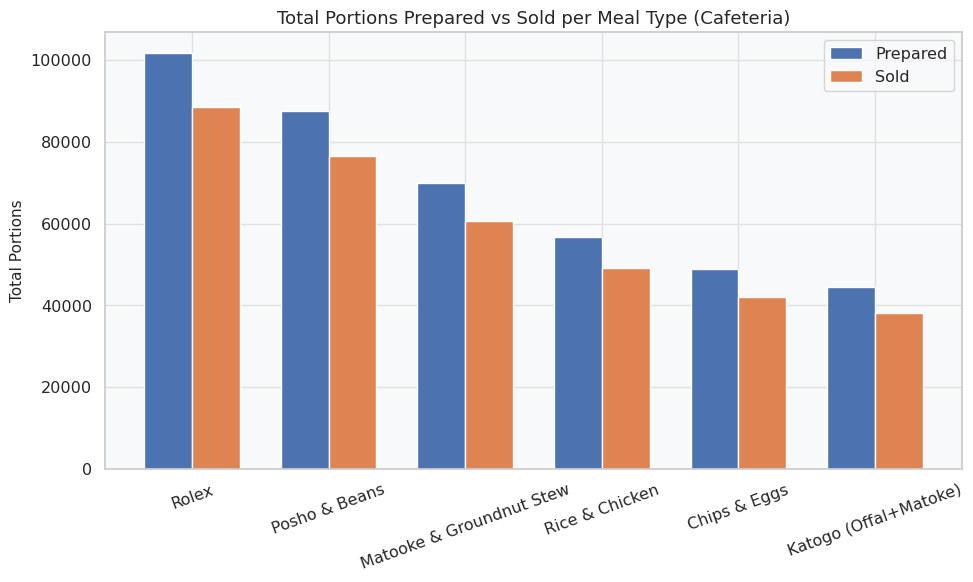

In [58]:

#1 bar plot comparing total portions prepared vs sold for each meal type in the cafeteria dataset   

# Group and summarize
meal_summary = (
    cafe.groupby('Meal')[['Portions_Prepared', 'Portions_Sold']]
    .sum()
    .sort_values('Portions_Prepared', ascending=False)
)

meals = meal_summary.index
prepared = meal_summary['Portions_Prepared']
sold = meal_summary['Portions_Sold']

x = np.arange(len(meals))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, prepared, width, label='Prepared')
plt.bar(x + width/2, sold, width, label='Sold')

plt.xticks(x, meals, rotation=20)
plt.ylabel('Total Portions')
plt.title('Total Portions Prepared vs Sold per Meal Type (Cafeteria)')
plt.legend()

plt.tight_layout()
plt.show()

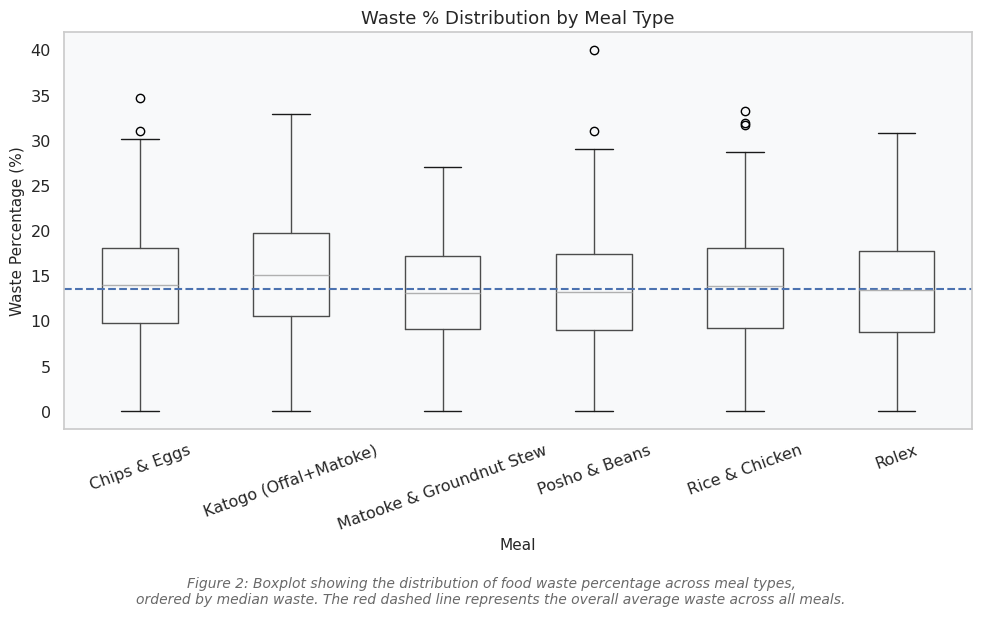

In [82]:
#2 boxplot showing distribution of waste % by meal type, ordered by median waste %

# Order meals by median waste %
meal_order = (
    cafe.groupby('Meal')['Waste_Pct']
    .median()
    .sort_values(ascending=False)
    .index
)

# Reorder dataframe
ordered_df = cafe.set_index('Meal').loc[meal_order].reset_index()

# Boxplot using pandas
ordered_df.boxplot(
    column='Waste_Pct',
    by='Meal',
    figsize=(10,6),
    grid=False
)

plt.title('Waste % Distribution by Meal Type')
plt.suptitle('')   # Removes automatic pandas subtitle
plt.ylabel('Waste Percentage (%)')
plt.xticks(rotation=20)

# Add overall average line
overall_avg = cafe['Waste_Pct'].mean()
plt.axhline(overall_avg, linestyle='--')
plt.figtext(
    0.5, -0.05,                          # x=centre, y=just below the plot
    "Figure 2: Boxplot showing the distribution of food waste percentage across meal types,\n"
    "ordered by median waste. The red dashed line represents the overall average waste across all meals.",
    ha='center',                         # horizontally centred
    fontsize=10,
    style='italic',
    color='dimgray',
    wrap=True
)

plt.tight_layout()
plt.show()

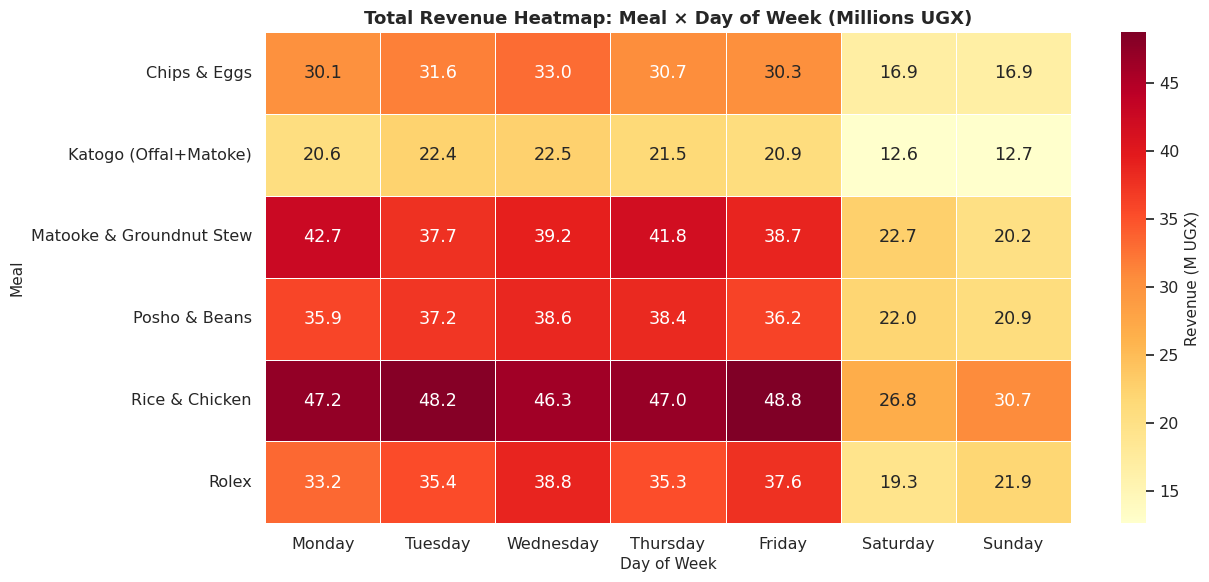

In [60]:
#3 correlation heatmap of total revenue by meal type and day of week in the cafeteria dataset
pivot_rev = cafe.pivot_table(values='Revenue_UGX', index='Meal',
                              columns='Day_of_Week', aggfunc='sum', observed=True)
pivot_rev = pivot_rev[DOW_ORDER]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot_rev/1e6, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Revenue (M UGX)'})
ax.set_title('Total Revenue Heatmap: Meal × Day of Week (Millions UGX)', fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Meal')
plt.tight_layout()
plt.show()

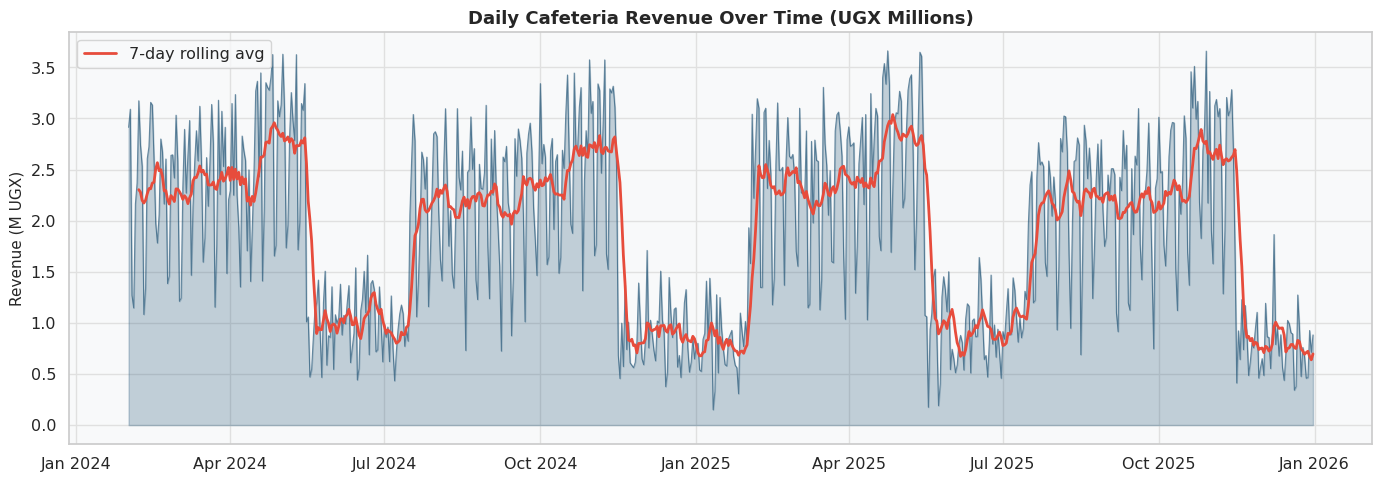

In [61]:
#4
daily_rev = cafe.groupby('Date')['Revenue_UGX'].sum().reset_index()
daily_rev['Rolling_7'] = daily_rev['Revenue_UGX'].rolling(7).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(daily_rev['Date'], daily_rev['Revenue_UGX']/1e6,
                alpha=0.25, color=MAKERERE_COLORS['primary'])
ax.plot(daily_rev['Date'], daily_rev['Revenue_UGX']/1e6,
        color=MAKERERE_COLORS['primary'], linewidth=0.8, alpha=0.6)
ax.plot(daily_rev['Date'], daily_rev['Rolling_7']/1e6,
        color=MAKERERE_COLORS['accent'], linewidth=2, label='7-day rolling avg')
ax.set_title('Daily Cafeteria Revenue Over Time (UGX Millions)', fontweight='bold')
ax.set_ylabel('Revenue (M UGX)')
ax.legend()
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

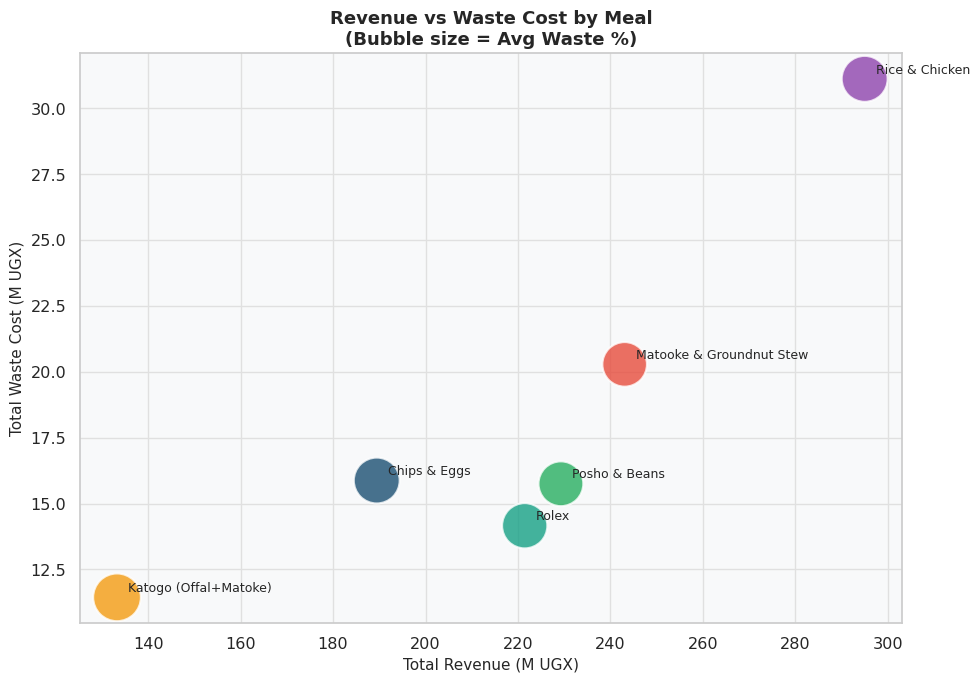

In [62]:
#5 scatter
 
scatter_data = cafe.groupby('Meal').agg(
    Revenue=('Revenue_UGX','sum'),
    Waste=('Waste_Cost_UGX','sum'),
    Avg_Waste_Pct=('Waste_Pct','mean')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(scatter_data['Revenue']/1e6, scatter_data['Waste']/1e6,
                     s=scatter_data['Avg_Waste_Pct']*80,
                     c=MEAL_COLORS[:len(scatter_data)], alpha=0.8, edgecolors='white', linewidth=1.5)
for _, row in scatter_data.iterrows():
    ax.annotate(row['Meal'],
                (row['Revenue']/1e6, row['Waste']/1e6),
                textcoords='offset points', xytext=(8, 4), fontsize=9)
ax.set_title('Revenue vs Waste Cost by Meal\n(Bubble size = Avg Waste %)', fontweight='bold')
ax.set_xlabel('Total Revenue (M UGX)')
ax.set_ylabel('Total Waste Cost (M UGX)')
plt.tight_layout()
plt.show()

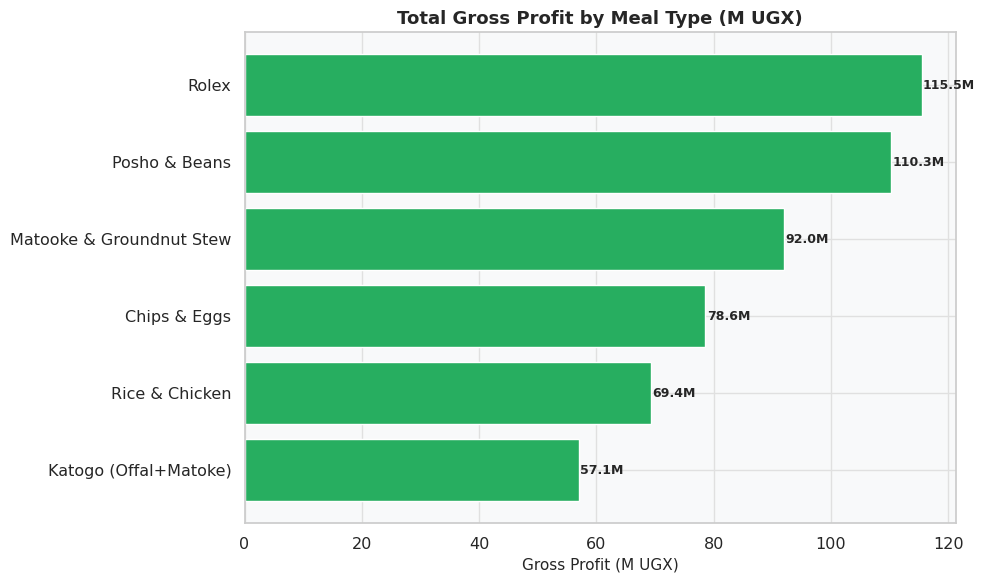

In [63]:
#6
profit = cafe.groupby('Meal')['Gross_Profit_UGX'].sum().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(profit.index, profit.values/1e6,
               color=[MAKERERE_COLORS['green'] if v>0 else MAKERERE_COLORS['accent']
                      for v in profit.values],
               edgecolor='white', linewidth=1)
ax.set_title('Total Gross Profit by Meal Type (M UGX)', fontweight='bold')
ax.set_xlabel('Gross Profit (M UGX)')
for bar in bars:
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.1f}M', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

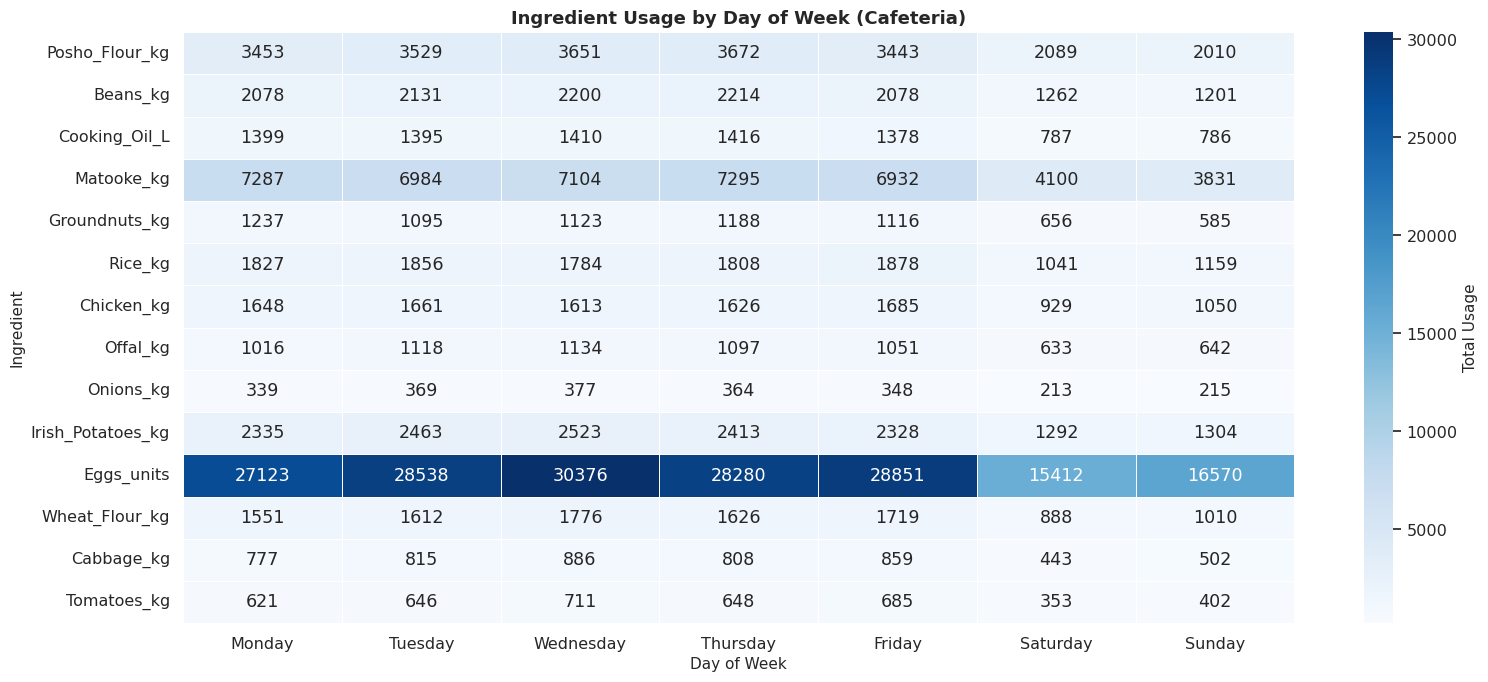

In [64]:
#7
ingredients = ['Posho_Flour_kg','Beans_kg','Cooking_Oil_L','Matooke_kg',
               'Groundnuts_kg','Rice_kg','Chicken_kg','Offal_kg',
               'Onions_kg','Irish_Potatoes_kg','Eggs_units','Wheat_Flour_kg',
               'Cabbage_kg','Tomatoes_kg']
ing_period = cafe.groupby('Day_of_Week', observed=True)[ingredients].sum()
ing_period.index = ing_period.index.astype(str)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(ing_period.T, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Total Usage'})
ax.set_title('Ingredient Usage by Day of Week (Cafeteria)', fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Ingredient')
plt.tight_layout()
plt.show()

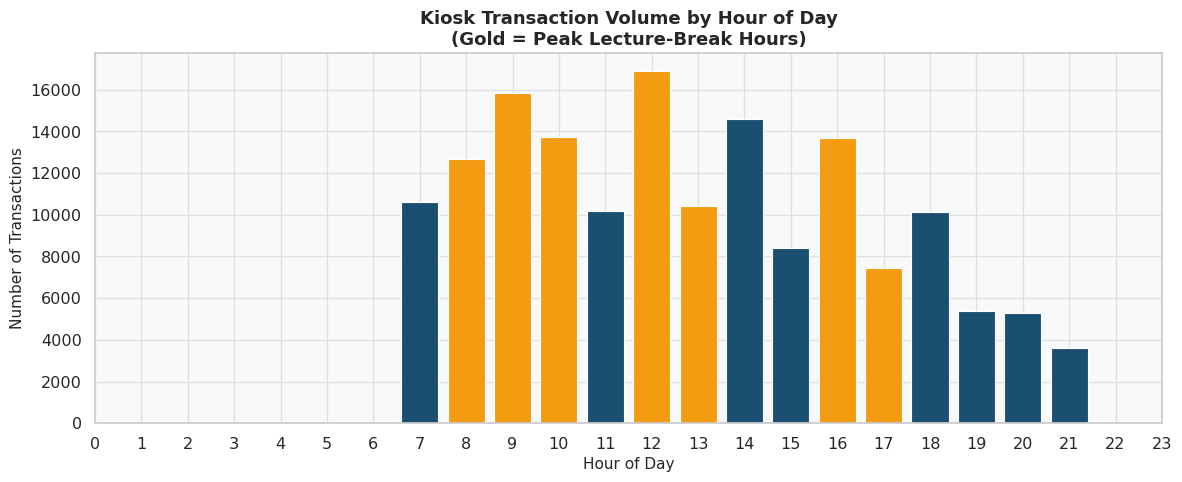

In [65]:
#8
hourly = kiosk.groupby('Hour').size().reset_index(name='Transactions')

fig, ax = plt.subplots(figsize=(12, 5))
colors_h = [MAKERERE_COLORS['secondary'] if h in [8,9,10,12,13,16,17]
            else MAKERERE_COLORS['primary'] for h in hourly['Hour']]
bars = ax.bar(hourly['Hour'], hourly['Transactions'], color=colors_h,
              edgecolor='white', linewidth=0.8)
ax.set_title('Kiosk Transaction Volume by Hour of Day\n(Gold = Peak Lecture-Break Hours)',
             fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Transactions')
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

In [66]:
print(kiosk.columns)


Index(['Transaction_ID', 'Date', 'Time', 'Hour', 'Day_of_Week',
       'Academic_Period', 'Is_Weekend', 'Near_Lecture_Start', 'Kiosk_ID',
       'Kiosk_Name', 'Kiosk_Location', 'Item', 'Quantity', 'Unit_Price_UGX',
       'Total_Amount_UGX', 'Payment_Method', 'Price_vs_Base_Pct'],
      dtype='object')


C:\Users\USER\AppData\Local\Temp\ipykernel_11400\3633738922.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(item_rev.index, rotation=20, ha='right')


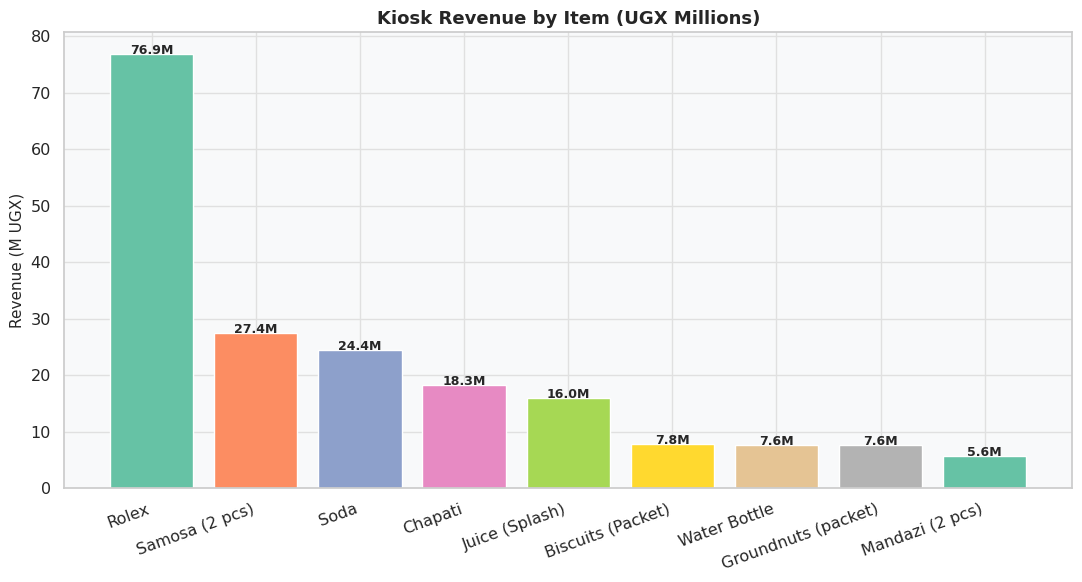

In [67]:
#9
item_rev = kiosk.groupby('Item')['Total_Amount_UGX'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
colors_i = sns.color_palette('Set2', len(item_rev))
bars = ax.bar(item_rev.index, item_rev.values/1e6, color=colors_i,
              edgecolor='white', linewidth=1)
ax.set_title('Kiosk Revenue by Item (UGX Millions)', fontweight='bold')
ax.set_ylabel('Revenue (M UGX)')
ax.set_xticklabels(item_rev.index, rotation=20, ha='right')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{bar.get_height():.1f}M', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

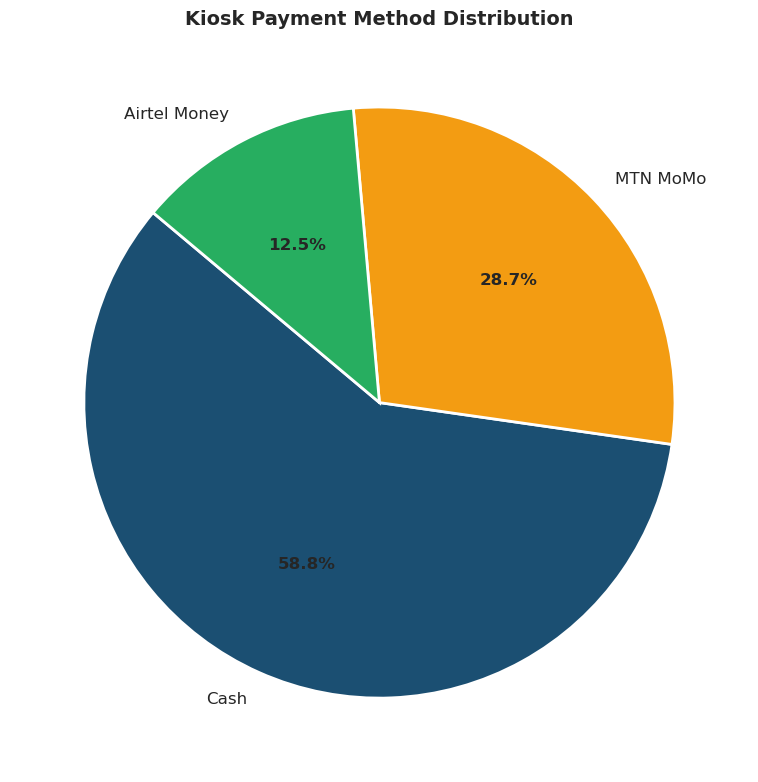

In [68]:
#10
payment = kiosk['Payment_Method'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    payment.values,
    labels=payment.index,
    autopct='%1.1f%%',
    colors=[MAKERERE_COLORS['primary'], MAKERERE_COLORS['secondary'], MAKERERE_COLORS['green']],
    startangle=140,
    wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize':12}
)
for at in autotexts:
    at.set_fontweight('bold')
ax.set_title('Kiosk Payment Method Distribution', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

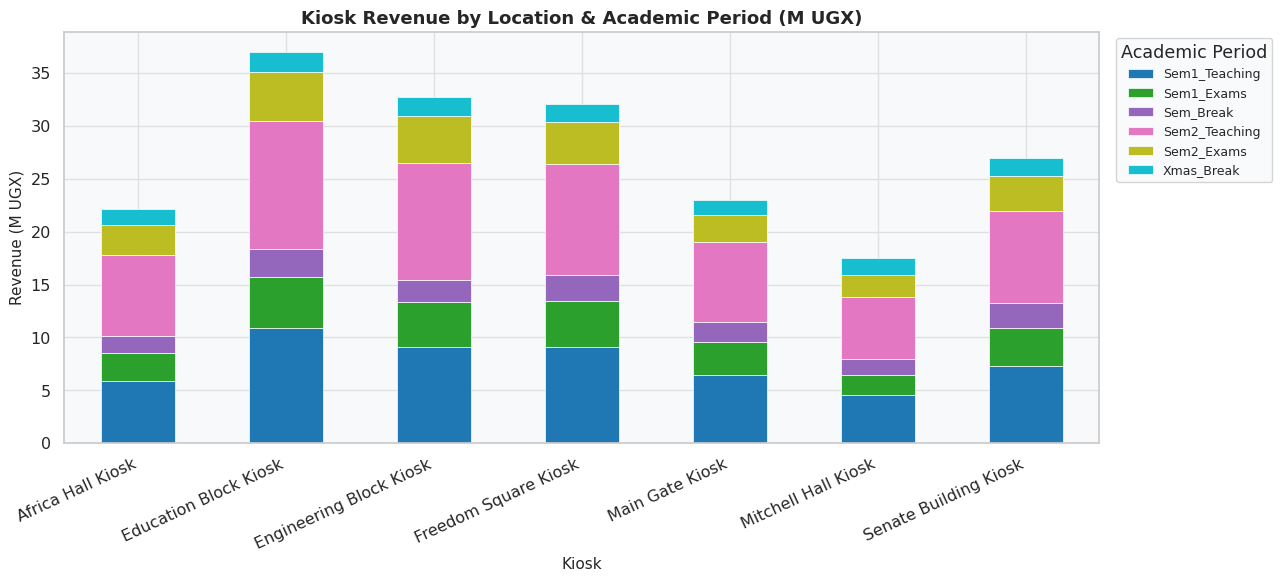

In [69]:
#11
kiosk_loc = kiosk.groupby(['Kiosk_Name','Academic_Period'], observed=True)['Total_Amount_UGX'].sum().unstack(fill_value=0)/1e6

fig, ax = plt.subplots(figsize=(13, 6))
kiosk_loc.plot(kind='bar', stacked=True, ax=ax,
               colormap='tab10', edgecolor='white', linewidth=0.5)
ax.set_title('Kiosk Revenue by Location & Academic Period (M UGX)', fontweight='bold')
ax.set_xlabel('Kiosk')
ax.set_ylabel('Revenue (M UGX)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.legend(title='Academic Period', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

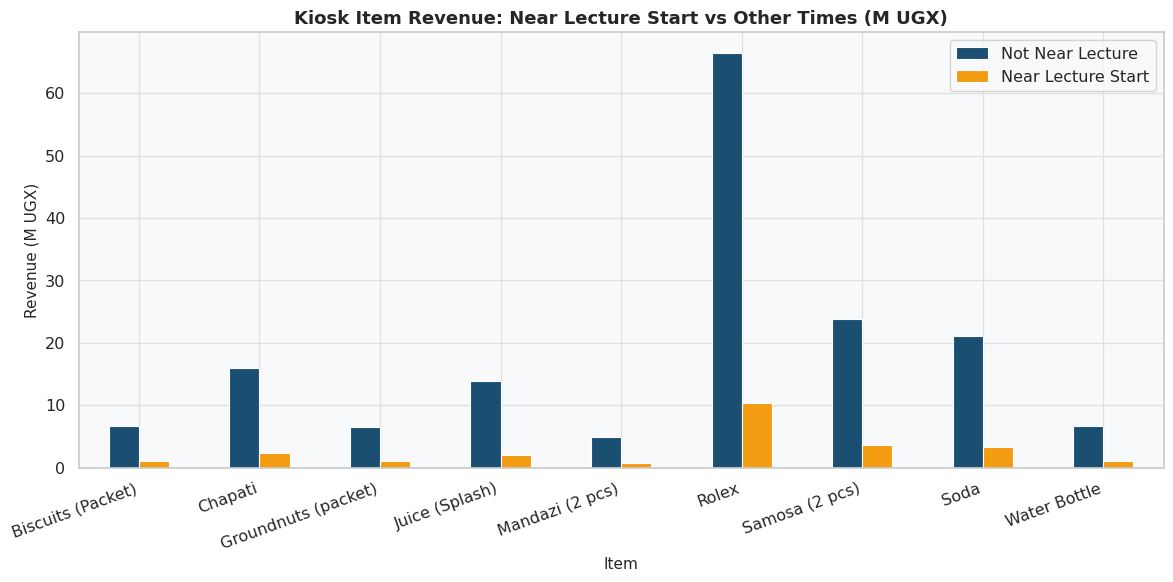

In [70]:
#12
lecture_effect = kiosk.groupby(['Near_Lecture_Start','Item'])['Total_Amount_UGX'].sum().unstack(fill_value=0)/1e6
lecture_effect.index = ['Not Near Lecture','Near Lecture Start']

fig, ax = plt.subplots(figsize=(12, 6))
lecture_effect.T.plot(kind='bar', ax=ax,
                      color=[MAKERERE_COLORS['primary'], MAKERERE_COLORS['secondary']],
                      edgecolor='white', linewidth=0.8)
ax.set_title('Kiosk Item Revenue: Near Lecture Start vs Other Times (M UGX)', fontweight='bold')
ax.set_ylabel('Revenue (M UGX)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

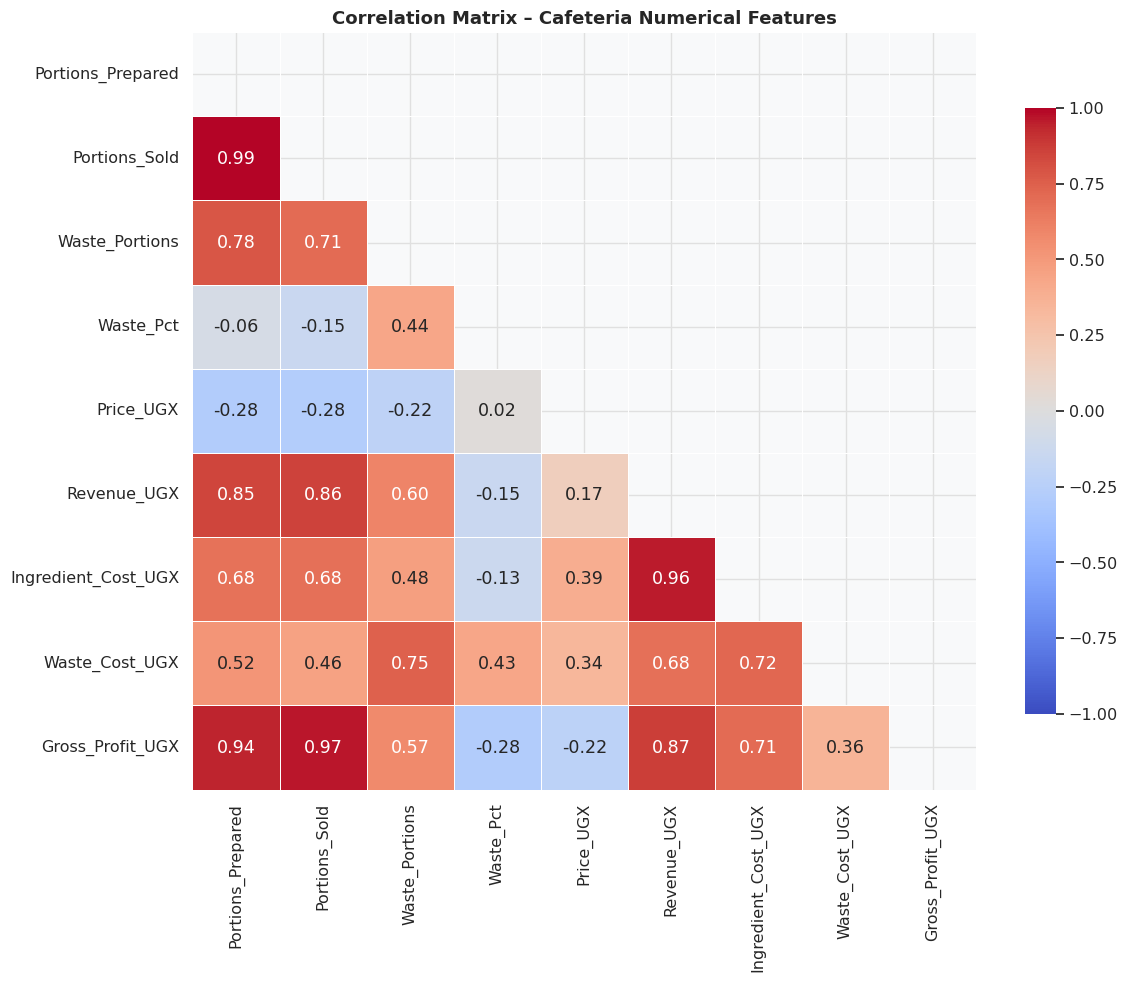

In [71]:



#13
num_cols = ['Portions_Prepared','Portions_Sold','Waste_Portions','Waste_Pct',
            'Price_UGX','Revenue_UGX','Ingredient_Cost_UGX','Waste_Cost_UGX','Gross_Profit_UGX']
corr = cafe[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'shrink':0.8})
ax.set_title('Correlation Matrix – Cafeteria Numerical Features', fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_11400\419537998.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=cafe, x='Day_of_Week', y='Portions_Sold',


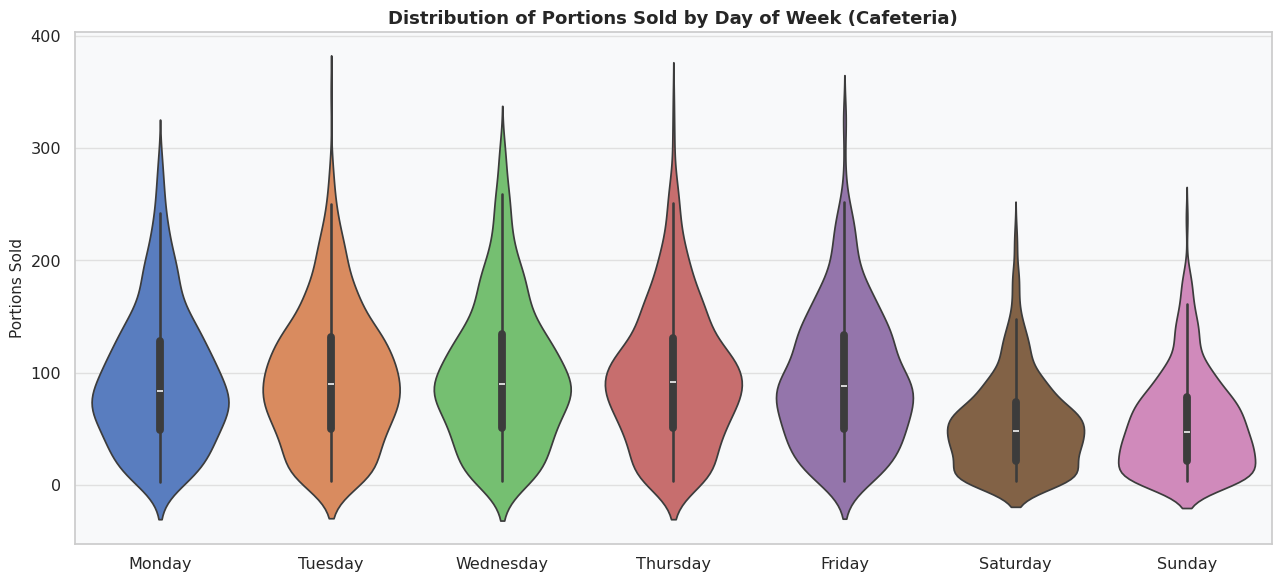

In [72]:
#14
fig, ax = plt.subplots(figsize=(13, 6))
sns.violinplot(data=cafe, x='Day_of_Week', y='Portions_Sold',
               order=DOW_ORDER, palette='muted', ax=ax, inner='box')
ax.set_title('Distribution of Portions Sold by Day of Week (Cafeteria)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Portions Sold')
plt.tight_layout()
plt.show()

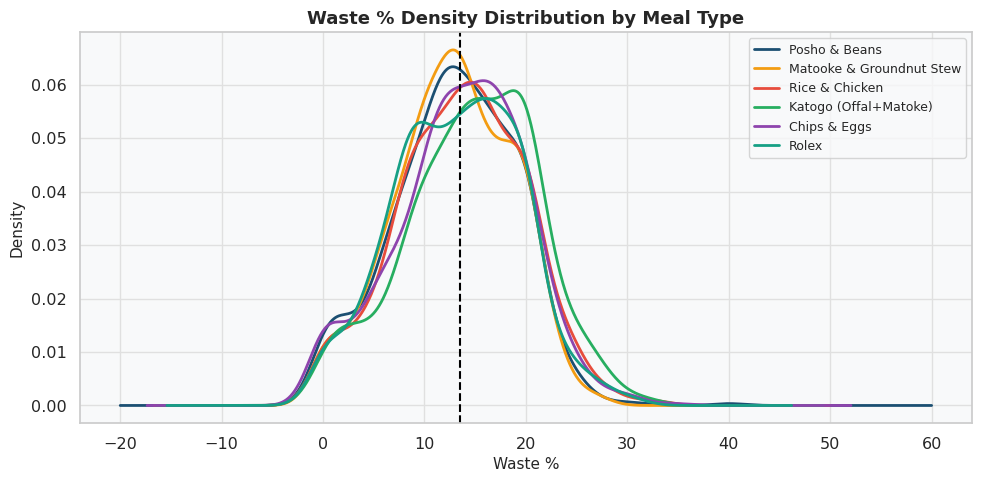

In [73]:
#15
fig, ax = plt.subplots(figsize=(10, 5))
for meal, color in zip(cafe['Meal'].unique(), MEAL_COLORS):
    subset = cafe[cafe['Meal']==meal]['Waste_Pct']
    subset.plot.kde(ax=ax, label=meal, color=color, linewidth=2)
ax.set_title('Waste % Density Distribution by Meal Type', fontweight='bold')
ax.set_xlabel('Waste %')
ax.set_ylabel('Density')
ax.legend(fontsize=9)
ax.axvline(cafe['Waste_Pct'].mean(), color='black', linestyle='--',
           linewidth=1.5, label='Overall Mean')
plt.tight_layout()
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_11400\3417924842.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(cafe_period.index.astype(str), rotation=30, ha='right')
C:\Users\USER\AppData\Local\Temp\ipykernel_11400\3417924842.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(kiosk_period.index.astype(str), rotation=30, ha='right')


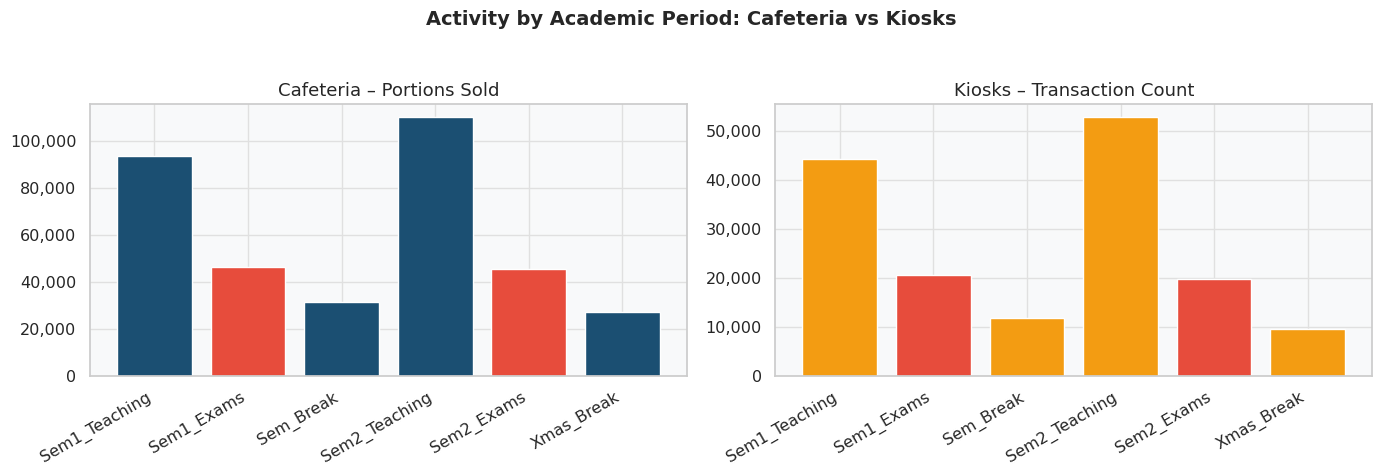

In [74]:
#16
from matplotlib import ticker as mticker


cafe_period  = cafe.groupby('Academic_Period', observed=True)['Portions_Sold'].sum()
kiosk_period = kiosk.groupby('Academic_Period', observed=True).size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Activity by Academic Period: Cafeteria vs Kiosks', fontweight='bold', fontsize=14)

colors_p2 = [MAKERERE_COLORS['accent'] if 'Exam' in str(p)
             else MAKERERE_COLORS['primary'] for p in cafe_period.index]
axes[0].bar(cafe_period.index.astype(str), cafe_period.values,
            color=colors_p2, edgecolor='white')
axes[0].set_title('Cafeteria – Portions Sold')
axes[0].set_xticklabels(cafe_period.index.astype(str), rotation=30, ha='right')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))

colors_p3 = [MAKERERE_COLORS['accent'] if 'Exam' in str(p)
             else MAKERERE_COLORS['secondary'] for p in kiosk_period.index]
axes[1].bar(kiosk_period.index.astype(str), kiosk_period.values,
            color=colors_p3, edgecolor='white')
axes[1].set_title('Kiosks – Transaction Count')
axes[1].set_xticklabels(kiosk_period.index.astype(str), rotation=30, ha='right')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{int(v):,}'))
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

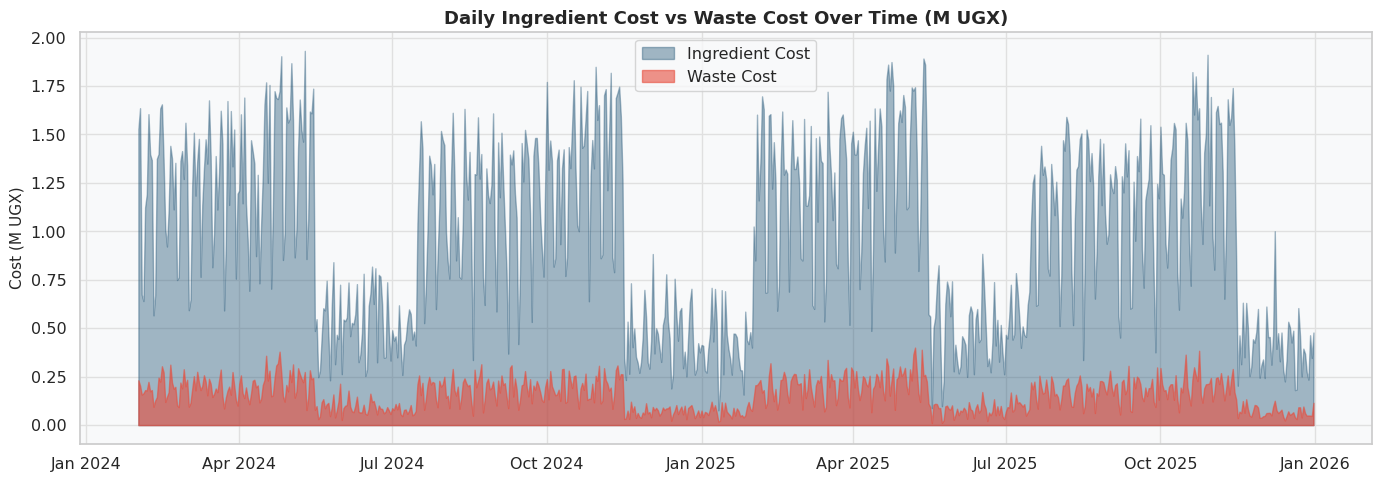

In [75]:
#17
daily_costs = cafe.groupby('Date').agg(
    Ingredient=('Ingredient_Cost_UGX','sum'),
    Waste=('Waste_Cost_UGX','sum')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(daily_costs['Date'], daily_costs['Ingredient']/1e6,
                alpha=0.4, color=MAKERERE_COLORS['primary'], label='Ingredient Cost')
ax.fill_between(daily_costs['Date'], daily_costs['Waste']/1e6,
                alpha=0.6, color=MAKERERE_COLORS['accent'], label='Waste Cost')
ax.set_title('Daily Ingredient Cost vs Waste Cost Over Time (M UGX)', fontweight='bold')
ax.set_ylabel('Cost (M UGX)')
ax.legend()
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

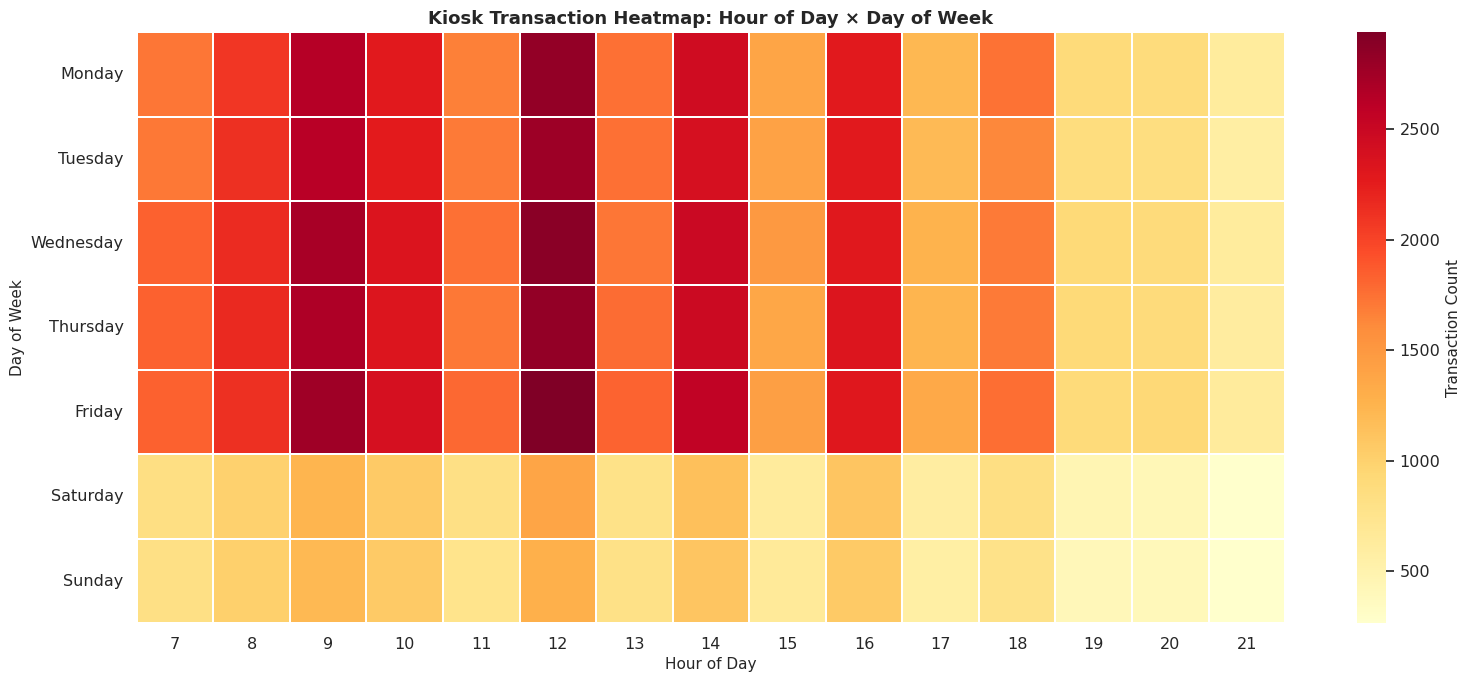

In [76]:
#18
heatmap_data = kiosk.groupby(['Day_of_Week','Hour'], observed=True).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(DOW_ORDER)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Transaction Count'})
ax.set_title('Kiosk Transaction Heatmap: Hour of Day × Day of Week', fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()


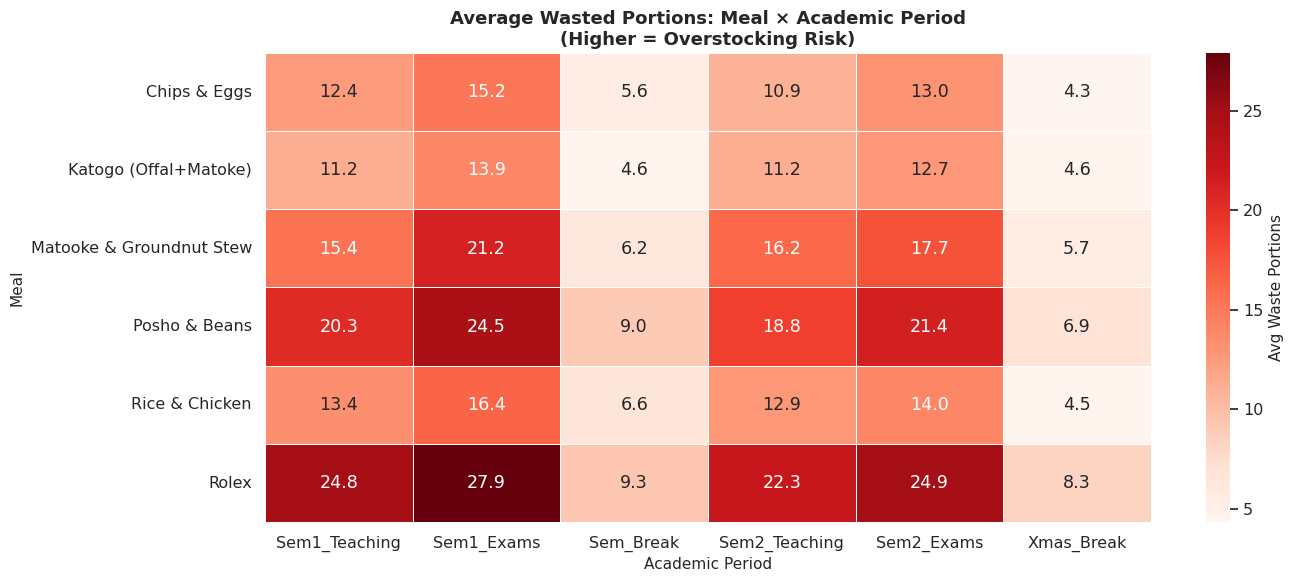

In [77]:
#19
overstock = cafe.groupby(['Meal','Academic_Period'], observed=True)['Waste_Portions'].mean().unstack(fill_value=0)
overstock.columns = overstock.columns.astype(str)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(overstock, annot=True, fmt='.1f', cmap='Reds',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Avg Waste Portions'})
ax.set_title('Average Wasted Portions: Meal × Academic Period\n(Higher = Overstocking Risk)',
             fontweight='bold')
ax.set_xlabel('Academic Period')
ax.set_ylabel('Meal')
plt.tight_layout()
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_11400\1404586507.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(eff.index, rotation=20, ha='right')


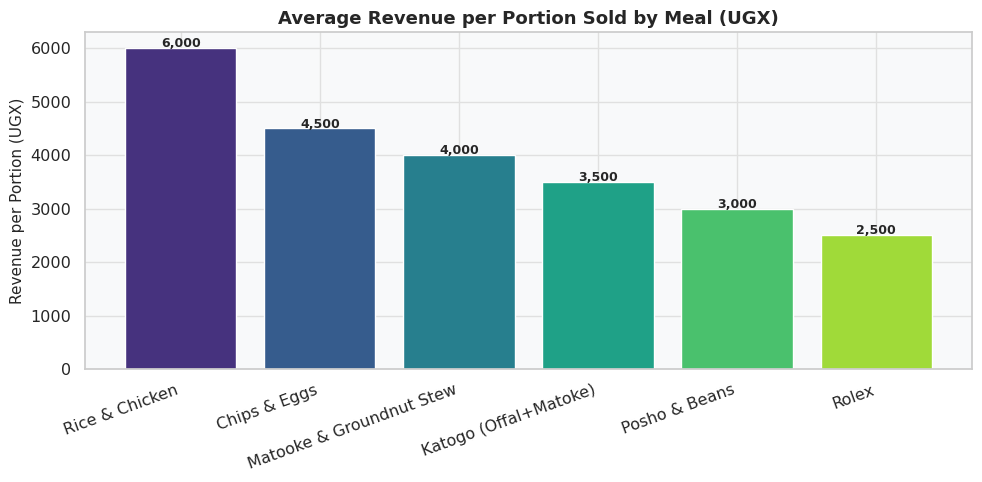

In [78]:
#20
cafe['Revenue_per_Portion'] = cafe['Revenue_UGX'] / cafe['Portions_Sold'].replace(0, np.nan)
eff = cafe.groupby('Meal')['Revenue_per_Portion'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_e = sns.color_palette('viridis', len(eff))
bars = ax.bar(eff.index, eff.values, color=colors_e, edgecolor='white', linewidth=1)
ax.set_title('Average Revenue per Portion Sold by Meal (UGX)', fontweight='bold')
ax.set_ylabel('Revenue per Portion (UGX)')
ax.set_xticklabels(eff.index, rotation=20, ha='right')
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{int(bar.get_height()):,}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

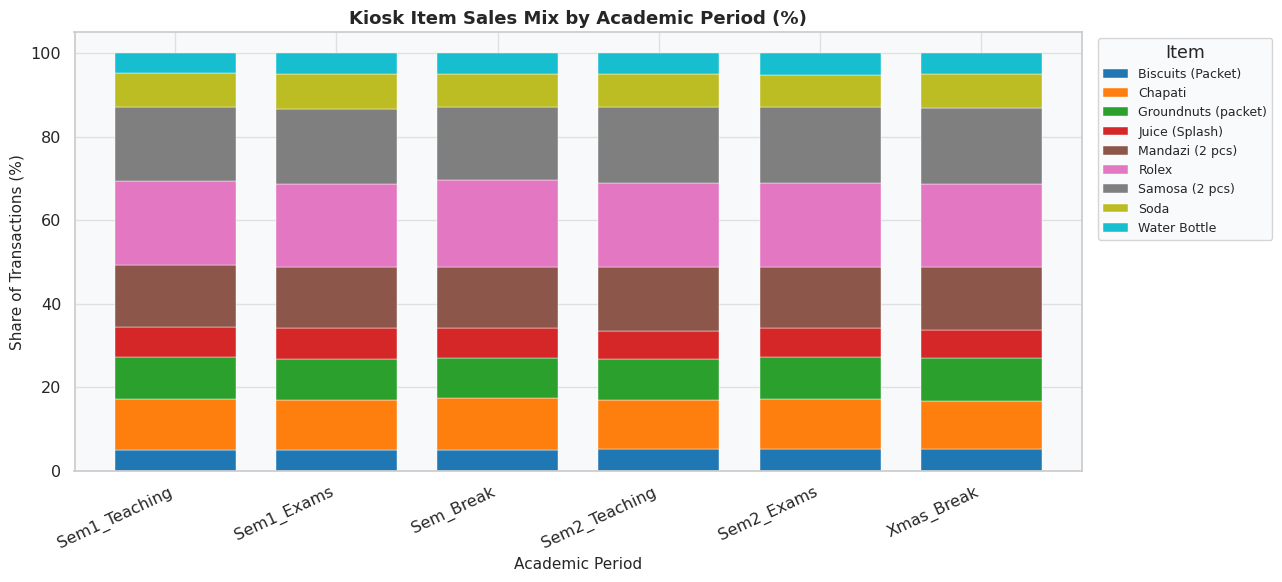

In [79]:
#21
item_period = kiosk.groupby(['Academic_Period','Item'], observed=True).size().unstack(fill_value=0)
item_period_pct = item_period.div(item_period.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(13, 6))
item_period_pct.plot(kind='bar', stacked=True, ax=ax,
                     colormap='tab10', edgecolor='white', linewidth=0.3, width=0.75)
ax.set_title('Kiosk Item Sales Mix by Academic Period (%)', fontweight='bold')
ax.set_ylabel('Share of Transactions (%)')
ax.set_xlabel('Academic Period')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.legend(title='Item', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

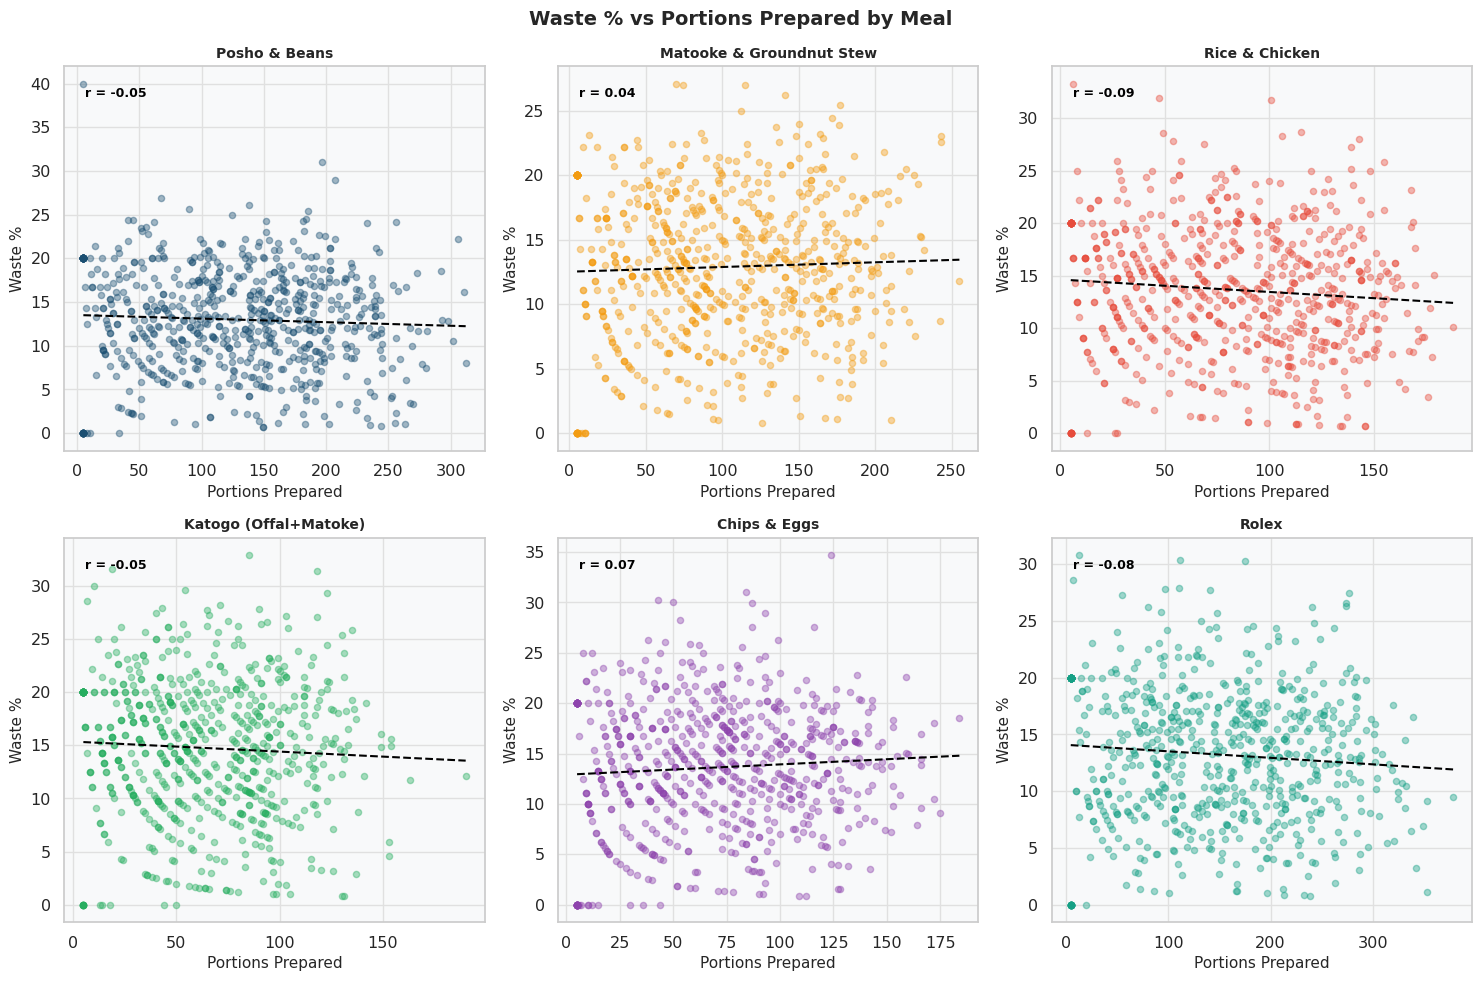

In [80]:
#22
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Waste % vs Portions Prepared by Meal', fontweight='bold', fontsize=14)
axes = axes.flatten()
for i, (meal, color) in enumerate(zip(cafe['Meal'].unique(), MEAL_COLORS)):
    sub = cafe[cafe['Meal']==meal]
    axes[i].scatter(sub['Portions_Prepared'], sub['Waste_Pct'],
                    alpha=0.4, color=color, s=20)
    m, b = np.polyfit(sub['Portions_Prepared'], sub['Waste_Pct'], 1)
    xline = np.linspace(sub['Portions_Prepared'].min(), sub['Portions_Prepared'].max(), 100)
    axes[i].plot(xline, m*xline+b, color='black', linewidth=1.5, linestyle='--')
    axes[i].set_title(meal, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Portions Prepared')
    axes[i].set_ylabel('Waste %')
    r = np.corrcoef(sub['Portions_Prepared'], sub['Waste_Pct'])[0,1]
    axes[i].text(0.05, 0.92, f'r = {r:.2f}', transform=axes[i].transAxes,
                 fontsize=9, color='black', fontweight='bold')
plt.tight_layout()
plt.show()

NameError: name 'mpatches' is not defined

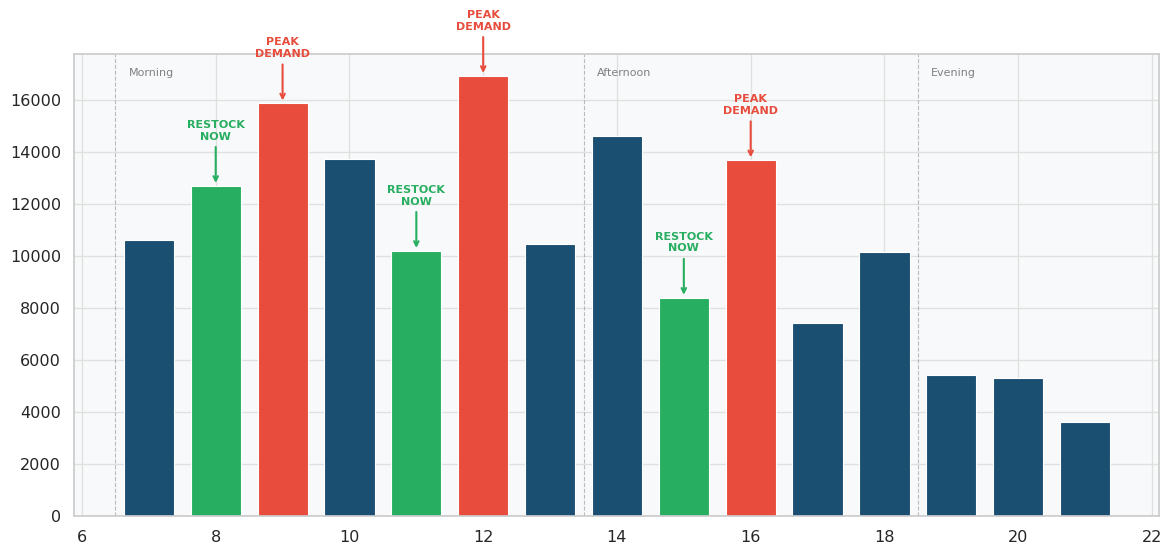

In [81]:
#23


for col in ['Unit_Price_UGX', 'Total_Amount_UGX']:
    kiosk[col] = kiosk[col].astype(str).str.replace(',', '').astype(float)

# ── Aggregate transactions by hour ──────────────────────────────
hourly = kiosk.groupby('Hour').size().reset_index(name='Transactions')
hourly['Revenue_M'] = kiosk.groupby('Hour')['Total_Amount_UGX'].sum().values / 1e6

# ── Define restocking windows (1 hour BEFORE each peak) ─────────
# Peaks are at 9, 12, 16 (lecture breaks) → restock at 8, 11, 15
PEAK_HOURS    = [9, 12, 16]
RESTOCK_HOURS = [8, 11, 15]

# ── Color code each bar ──────────────────────────────────────────
def bar_color(h):
    if h in PEAK_HOURS:    return '#E74C3C'   # red = peak demand
    if h in RESTOCK_HOURS: return '#27AE60'   # green = restock now
    return '#1B4F72'                           # blue = normal

colors = [bar_color(h) for h in hourly['Hour']]

# ── Plot ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(hourly['Hour'], hourly['Transactions'],
              color=colors, edgecolor='white', linewidth=0.8, width=0.75)

# Annotate restock windows with arrows
for rh in RESTOCK_HOURS:
    row = hourly[hourly['Hour'] == rh]
    if not row.empty:
        y = row['Transactions'].values[0]
        ax.annotate('RESTOCK\nNOW',
                    xy=(rh, y), xytext=(rh, y + 1800),
                    ha='center', fontsize=8, fontweight='bold', color='#27AE60',
                    arrowprops=dict(arrowstyle='->', color='#27AE60', lw=1.5))

# Annotate peak hours
for ph in PEAK_HOURS:
    row = hourly[hourly['Hour'] == ph]
    if not row.empty:
        y = row['Transactions'].values[0]
        ax.annotate('PEAK\nDEMAND',
                    xy=(ph, y), xytext=(ph, y + 1800),
                    ha='center', fontsize=8, fontweight='bold', color='#E74C3C',
                    arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=1.5))

# Add vertical dividers for morning / afternoon / evening
for x, label in [(6.5, 'Morning'), (13.5, 'Afternoon'), (18.5, 'Evening')]:
    ax.axvline(x, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.text(x + 0.2, ax.get_ylim()[1] * 0.97, label,
            fontsize=8, color='grey', va='top')

# Legend
legend_handles = [
    mpatches.Patch(color='#E74C3C', label='Peak Demand Hours'),
    mpatches.Patch(color='#27AE60', label='Recommended Restock Window'),
    mpatches.Patch(color='#1B4F72', label='Normal Hours'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9)

ax.set_title('Kiosk – Optimal Restocking Windows by Hour of Day\n'
             'Restock 1 hour BEFORE each peak demand period',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Number of Transactions')
ax.set_xticks(range(7, 21))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.set_facecolor('#F8F9FA')

plt.tight_layout()
plt.show()

print("\nRESTOCK SCHEDULE RECOMMENDATION:")
print("  08:00  → Restock before 09:00 lecture break rush")
print("  11:00  → Restock before 12:00 lunch rush")
print("  15:00  → Restock before 16:00 afternoon break rush")






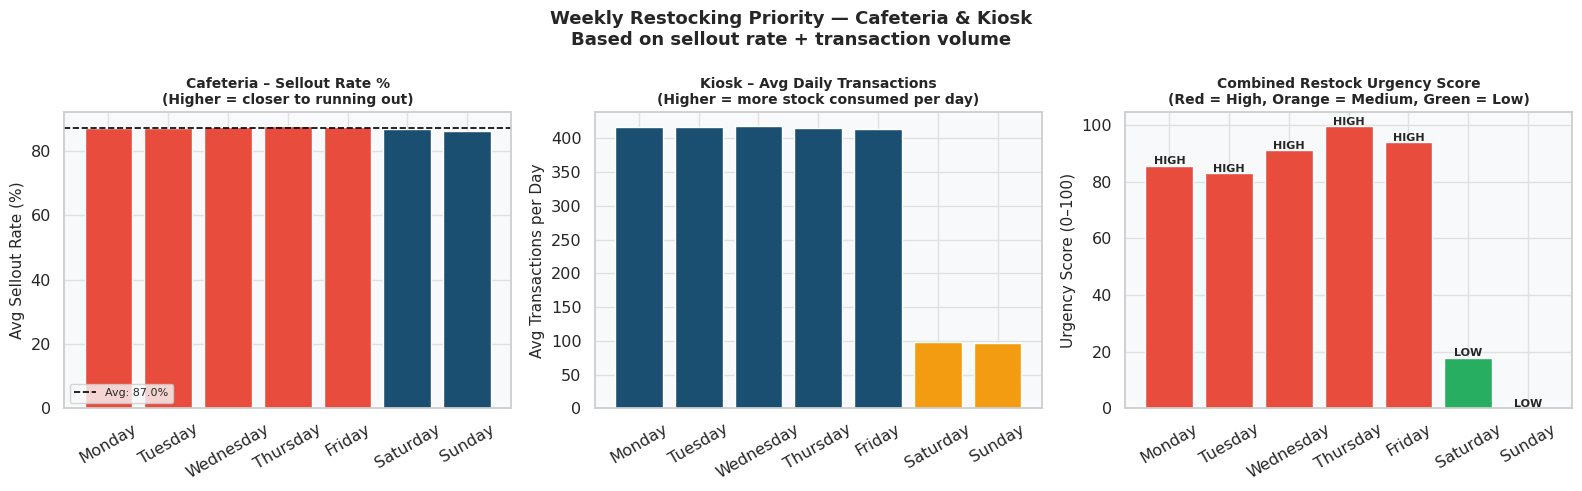


RESTOCK PRIORITY BY DAY:
  Thursday     Score: 99.6  →  HIGH  🔴
  Friday       Score: 93.9  →  HIGH  🔴
  Wednesday    Score: 91.2  →  HIGH  🔴
  Monday       Score: 85.6  →  HIGH  🔴
  Tuesday      Score: 82.9  →  HIGH  🔴
  Saturday     Score: 17.9  →  LOW    🟢
  Sunday       Score: 0.0  →  LOW    🟢


In [ ]:

#24
for col in ['Price_UGX','Revenue_UGX','Ingredient_Cost_UGX','Waste_Cost_UGX','Gross_Profit_UGX']:
    cafe[col] = cafe[col].astype(str).str.replace(',','').astype(float)
for col in ['Unit_Price_UGX','Total_Amount_UGX']:
    kiosk[col] = kiosk[col].astype(str).str.replace(',','').astype(float)

cafe['Day_of_Week']  = pd.Categorical(cafe['Day_of_Week'],  categories=DOW_ORDER, ordered=True)
kiosk['Day_of_Week'] = pd.Categorical(kiosk['Day_of_Week'], categories=DOW_ORDER, ordered=True)

# ── Cafeteria: sellout rate per day (high sellout = near stockout = restock urgently) ──
cafe['Sellout_Rate'] = cafe['Portions_Sold'] / cafe['Portions_Prepared'] * 100
cafe_sellout = (cafe.groupby('Day_of_Week', observed=True)['Sellout_Rate']
                .mean().reindex(DOW_ORDER))

# ── Kiosk: average daily transactions per day ──
kiosk_daily = (kiosk.groupby(['Date','Day_of_Week'], observed=True)
               .size()
               .groupby('Day_of_Week', observed=True)
               .mean()
               .reindex(DOW_ORDER))

# ── Restock urgency score: normalize both 0-100 and average ──
cafe_norm  = (cafe_sellout  - cafe_sellout.min())  / (cafe_sellout.max()  - cafe_sellout.min())  * 100
kiosk_norm = (kiosk_daily   - kiosk_daily.min())   / (kiosk_daily.max()   - kiosk_daily.min())   * 100
urgency    = ((cafe_norm + kiosk_norm) / 2).reindex(DOW_ORDER)

# ── Assign urgency labels ──
def urgency_label(score):
    if score >= 60: return '#E74C3C'    # High
    if score >= 35: return '#F39C12'    # Medium
    return '#27AE60'                    # Low

colors = [urgency_label(s) for s in urgency.values]

# ── Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Weekly Restocking Priority — Cafeteria & Kiosk\n'
             'Based on sellout rate + transaction volume',
             fontweight='bold', fontsize=13)

# Panel 1: Cafe sellout rate
axes[0].bar(DOW_ORDER, cafe_sellout.values,
            color=['#E74C3C' if v >= cafe_sellout.mean() else '#1B4F72'
                   for v in cafe_sellout.values],
            edgecolor='white')
axes[0].axhline(cafe_sellout.mean(), color='black', linestyle='--', linewidth=1.2,
                label=f'Avg: {cafe_sellout.mean():.1f}%')
axes[0].set_title('Cafeteria – Sellout Rate %\n(Higher = closer to running out)',
                  fontweight='bold', fontsize=10)
axes[0].set_ylabel('Avg Sellout Rate (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=8)
axes[0].set_facecolor('#F8F9FA')

# Panel 2: Kiosk average daily transactions
axes[1].bar(DOW_ORDER, kiosk_daily.values,
            color=['#F39C12' if d in ['Saturday','Sunday'] else '#1B4F72'
                   for d in DOW_ORDER],
            edgecolor='white')
axes[1].set_title('Kiosk – Avg Daily Transactions\n(Higher = more stock consumed per day)',
                  fontweight='bold', fontsize=10)
axes[1].set_ylabel('Avg Transactions per Day')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{int(v):,}'))
axes[1].set_facecolor('#F8F9FA')

# Panel 3: Combined urgency score
bars = axes[2].bar(DOW_ORDER, urgency.values, color=colors, edgecolor='white')
axes[2].set_title('Combined Restock Urgency Score\n(Red = High, Orange = Medium, Green = Low)',
                  fontweight='bold', fontsize=10)
axes[2].set_ylabel('Urgency Score (0–100)')
axes[2].tick_params(axis='x', rotation=30)
axes[2].set_facecolor('#F8F9FA')

# Label each bar with urgency level
for bar, score in zip(bars, urgency.values):
    label = 'HIGH' if score >= 60 else ('MED' if score >= 35 else 'LOW')
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 label, ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nRESTOCK PRIORITY BY DAY:")
for day, score in urgency.sort_values(ascending=False).items():
    level = 'HIGH  🔴' if score >= 60 else ('MEDIUM 🟡' if score >= 35 else 'LOW    🟢')
    print(f"  {str(day):<12} Score: {score:.1f}  →  {level}")

posx and posy should be finite values
posx and posy should be finite values


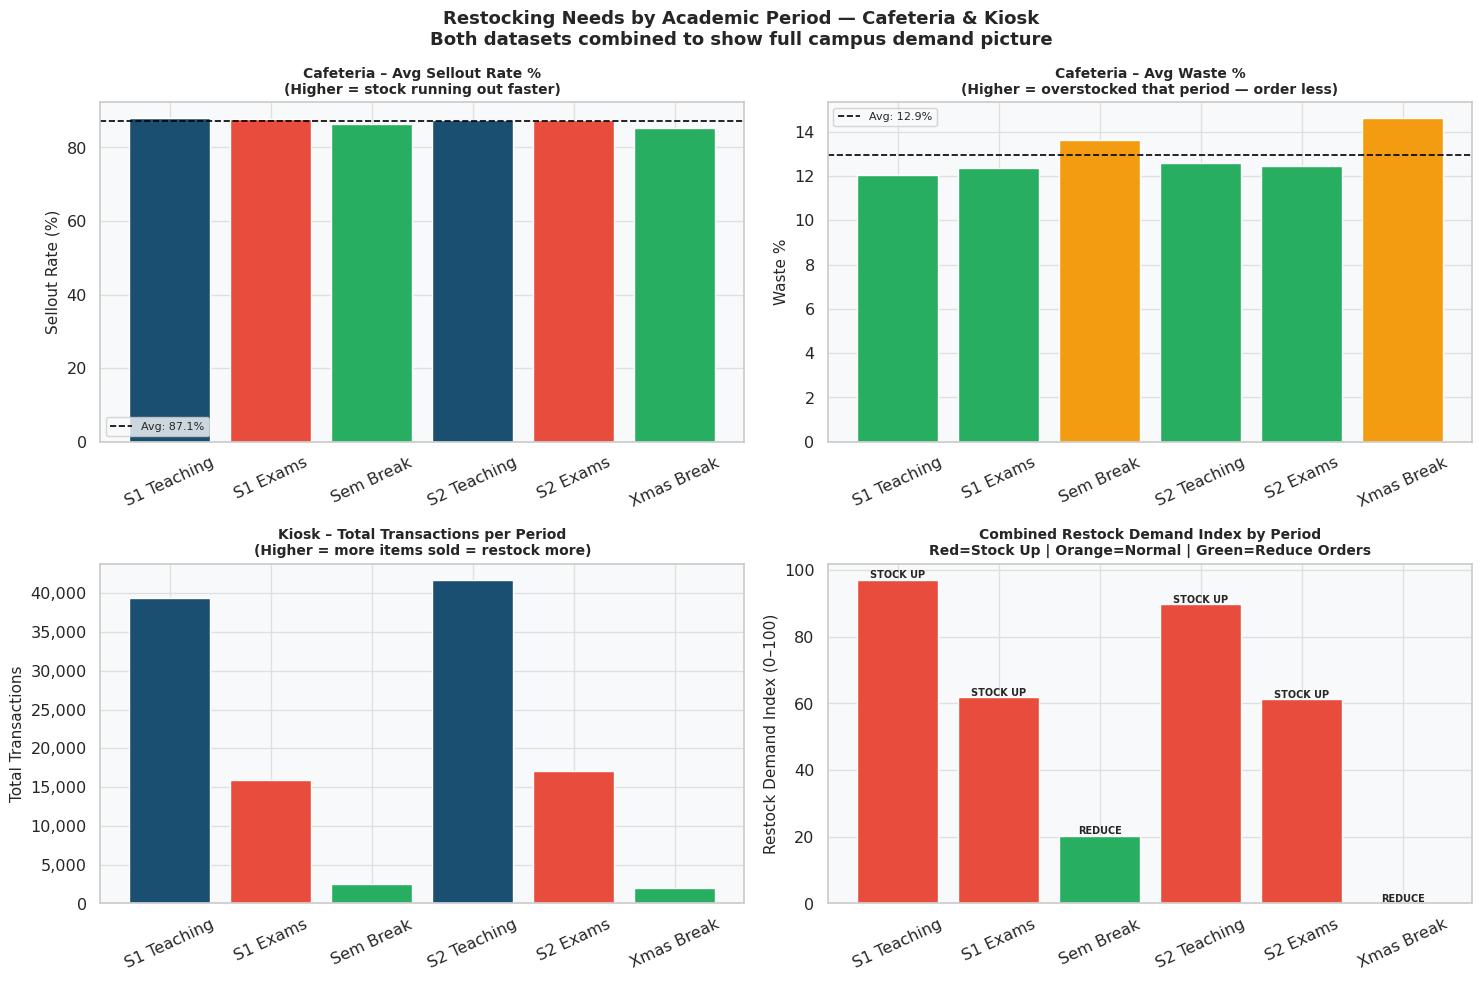


RESTOCK STRATEGY BY ACADEMIC PERIOD:
Period          Cafe Sellout  Waste %   Kiosk Txns          Action
-----------------------------------------------------------------
  Sem1_Teaching        87.9%    12.1%       39,401 STOCK UP
  Sem1_Exams           87.6%    12.4%       15,981 STOCK UP
  Sem_Break            86.4%    13.6%        2,573 REDUCE ORDERS
  Sem2_Teaching        87.4%    12.6%       41,728 STOCK UP
  Sem2_Exams           87.5%    12.4%       17,040 STOCK UP
  Xmas_Break           85.4%    14.6%        1,973 REDUCE ORDERS
  Other                 nan%     nan%          nan REDUCE ORDERS


In [ ]:

#24
for col in ['Price_UGX','Revenue_UGX','Ingredient_Cost_UGX','Waste_Cost_UGX','Gross_Profit_UGX']:
    cafe[col] = cafe[col].astype(str).str.replace(',','').astype(float)
for col in ['Unit_Price_UGX','Total_Amount_UGX']:
    kiosk[col] = kiosk[col].astype(str).str.replace(',','').astype(float)

cafe['Academic_Period']  = pd.Categorical(cafe['Academic_Period'],  categories=PERIOD_ORDER, ordered=True)
kiosk['Academic_Period'] = pd.Categorical(kiosk['Academic_Period'], categories=PERIOD_ORDER, ordered=True)

# ── Cafeteria metrics per period ─────────────────────────────────
cafe['Sellout_Rate'] = cafe['Portions_Sold'] / cafe['Portions_Prepared'] * 100

cafe_period = (cafe.groupby('Academic_Period', observed=True)
               .agg(Avg_Sellout=('Sellout_Rate','mean'),
                    Avg_Waste_Pct=('Waste_Pct','mean'),
                    Total_Portions_Sold=('Portions_Sold','sum'))
               .reindex(PERIOD_ORDER))

# ── Kiosk metrics per period ─────────────────────────────────────
kiosk_period = (kiosk.groupby('Academic_Period', observed=True)
                .agg(Total_Transactions=('Transaction_ID','count'),
                     Total_Revenue=('Total_Amount_UGX','sum'))
                .reindex(PERIOD_ORDER))
kiosk_period['Revenue_M'] = kiosk_period['Total_Revenue'] / 1e6

# ── Restock demand index: high sellout + high transactions = restock more ──
s_norm = (cafe_period['Avg_Sellout']            - cafe_period['Avg_Sellout'].min()) / \
         (cafe_period['Avg_Sellout'].max()       - cafe_period['Avg_Sellout'].min()) * 100
k_norm = (kiosk_period['Total_Transactions']    - kiosk_period['Total_Transactions'].min()) / \
         (kiosk_period['Total_Transactions'].max() - kiosk_period['Total_Transactions'].min()) * 100
restock_index = ((s_norm + k_norm) / 2)

# ── Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Restocking Needs by Academic Period — Cafeteria & Kiosk\n'
             'Both datasets combined to show full campus demand picture',
             fontweight='bold', fontsize=13)

period_colors = ['#E74C3C' if 'Exam' in p else
                 '#27AE60' if 'Break' in p else
                 '#1B4F72' for p in PERIOD_ORDER]

# Panel A: Cafeteria sellout rate
axes[0,0].bar(SHORT_LABELS, cafe_period['Avg_Sellout'].values,
              color=period_colors, edgecolor='white')
axes[0,0].axhline(cafe_period['Avg_Sellout'].mean(), color='black',
                  linestyle='--', linewidth=1.2,
                  label=f"Avg: {cafe_period['Avg_Sellout'].mean():.1f}%")
axes[0,0].set_title('Cafeteria – Avg Sellout Rate %\n(Higher = stock running out faster)',
                    fontweight='bold', fontsize=10)
axes[0,0].set_ylabel('Sellout Rate (%)')
axes[0,0].tick_params(axis='x', rotation=25)
axes[0,0].legend(fontsize=8)
axes[0,0].set_facecolor('#F8F9FA')

# Panel B: Cafeteria waste % (inverse — high waste = over-stocked)
axes[0,1].bar(SHORT_LABELS, cafe_period['Avg_Waste_Pct'].values,
              color=['#F39C12' if v > cafe_period['Avg_Waste_Pct'].mean()
                     else '#27AE60' for v in cafe_period['Avg_Waste_Pct'].values],
              edgecolor='white')
axes[0,1].axhline(cafe_period['Avg_Waste_Pct'].mean(), color='black',
                  linestyle='--', linewidth=1.2,
                  label=f"Avg: {cafe_period['Avg_Waste_Pct'].mean():.1f}%")
axes[0,1].set_title('Cafeteria – Avg Waste %\n(Higher = overstocked that period — order less)',
                    fontweight='bold', fontsize=10)
axes[0,1].set_ylabel('Waste %')
axes[0,1].tick_params(axis='x', rotation=25)
axes[0,1].legend(fontsize=8)
axes[0,1].set_facecolor('#F8F9FA')

# Panel C: Kiosk transactions per period
axes[1,0].bar(SHORT_LABELS, kiosk_period['Total_Transactions'].values,
              color=period_colors, edgecolor='white')
axes[1,0].set_title('Kiosk – Total Transactions per Period\n(Higher = more items sold = restock more)',
                    fontweight='bold', fontsize=10)
axes[1,0].set_ylabel('Total Transactions')
axes[1,0].tick_params(axis='x', rotation=25)
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{int(v):,}'))
axes[1,0].set_facecolor('#F8F9FA')

# Panel D: Combined restock demand index
bar_colors_d = ['#E74C3C' if v >= 60 else '#F39C12' if v >= 35 else '#27AE60'
                for v in restock_index.values]
bars = axes[1,1].bar(SHORT_LABELS, restock_index.values,
                     color=bar_colors_d, edgecolor='white')
axes[1,1].set_title('Combined Restock Demand Index by Period\n'
                    'Red=Stock Up | Orange=Normal | Green=Reduce Orders',
                    fontweight='bold', fontsize=10)
axes[1,1].set_ylabel('Restock Demand Index (0–100)')
axes[1,1].tick_params(axis='x', rotation=25)
axes[1,1].set_facecolor('#F8F9FA')

for bar, val in zip(bars, restock_index.values):
    label = 'STOCK UP' if val >= 60 else ('NORMAL' if val >= 35 else 'REDUCE')
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.5,
                   label, ha='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nRESTOCK STRATEGY BY ACADEMIC PERIOD:")
print(f"{'Period':<15} {'Cafe Sellout':>12} {'Waste %':>8} {'Kiosk Txns':>12} {'Action':>15}")
print("-" * 65)
for i, period in enumerate(PERIOD_ORDER):
    sellout = cafe_period.loc[period,'Avg_Sellout']
    waste   = cafe_period.loc[period,'Avg_Waste_Pct']
    txns    = kiosk_period.loc[period,'Total_Transactions']
    score   = restock_index.loc[period]
    action  = 'STOCK UP' if score >= 60 else ('NORMAL' if score >= 35 else 'REDUCE ORDERS')
    print(f"  {period:<13} {sellout:>11.1f}% {waste:>7.1f}% {txns:>12,.0f} {action}")

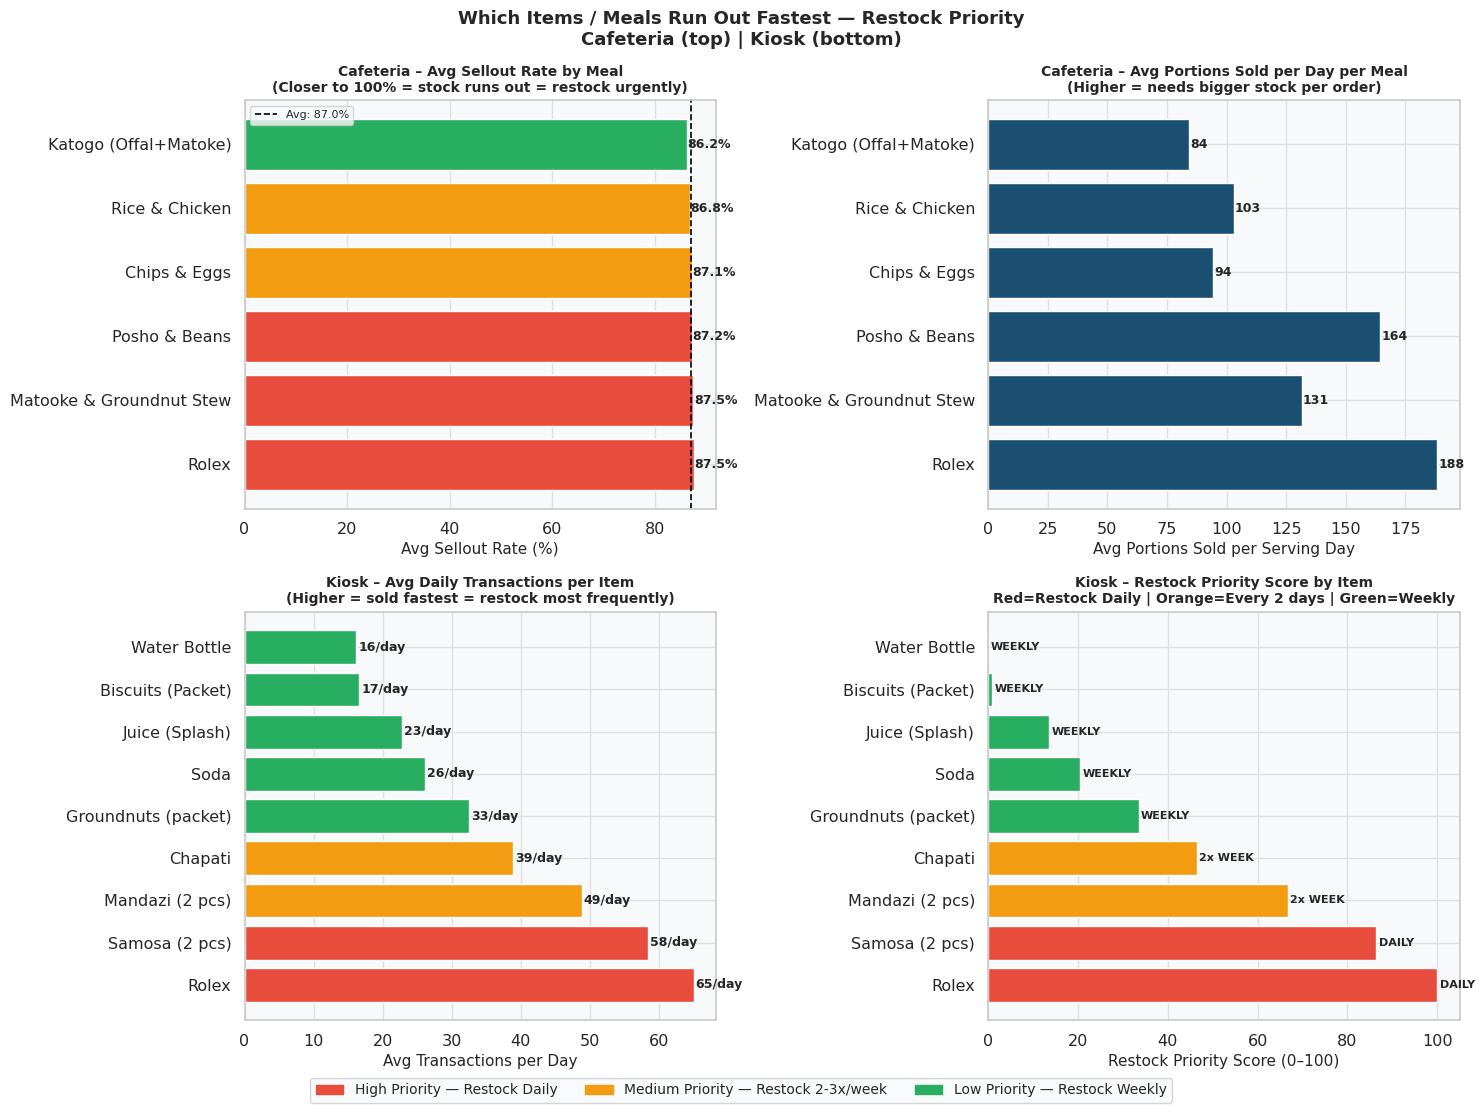


CAFETERIA RESTOCK ORDER (fastest selling first):
  Rolex                        Sellout: 87.5%  →  Daily
  Matooke & Groundnut Stew     Sellout: 87.5%  →  Daily
  Posho & Beans                Sellout: 87.2%  →  Daily
  Chips & Eggs                 Sellout: 87.1%  →  2-3x/week
  Rice & Chicken               Sellout: 86.8%  →  2-3x/week
  Katogo (Offal+Matoke)        Sellout: 86.2%  →  Weekly

KIOSK RESTOCK ORDER (highest demand velocity first):
  Rolex                     Avg 65 txns/day  →  Daily
  Samosa (2 pcs)            Avg 58 txns/day  →  Daily
  Mandazi (2 pcs)           Avg 49 txns/day  →  2-3x/week
  Chapati                   Avg 39 txns/day  →  2-3x/week
  Groundnuts (packet)       Avg 33 txns/day  →  Weekly
  Soda                      Avg 26 txns/day  →  Weekly
  Juice (Splash)            Avg 23 txns/day  →  Weekly
  Biscuits (Packet)         Avg 17 txns/day  →  Weekly
  Water Bottle              Avg 16 txns/day  →  Weekly


In [ ]:


#25
for col in ['Price_UGX','Revenue_UGX','Ingredient_Cost_UGX','Waste_Cost_UGX','Gross_Profit_UGX']:
    cafe[col] = cafe[col].astype(str).str.replace(',','').astype(float)
for col in ['Unit_Price_UGX','Total_Amount_UGX']:
    kiosk[col] = kiosk[col].astype(str).str.replace(',','').astype(float)

# ── CAFETERIA: sellout rate + avg portions sold per day ──────────
cafe['Sellout_Rate'] = cafe['Portions_Sold'] / cafe['Portions_Prepared'] * 100

cafe_meals = (cafe.groupby('Meal')
              .agg(Avg_Sellout_Rate=('Sellout_Rate','mean'),
                   Avg_Portions_Sold=('Portions_Sold','mean'),
                   Avg_Waste_Pct=('Waste_Pct','mean'))
              .sort_values('Avg_Sellout_Rate', ascending=False)
              .reset_index())

# ── KIOSK: avg transactions per day per item (demand velocity) ───
kiosk['Date'] = pd.to_datetime(kiosk['Date'])
n_days = kiosk['Date'].nunique()

kiosk_items = (kiosk.groupby('Item')
               .agg(Total_Transactions=('Transaction_ID','count'),
                    Total_Revenue=('Total_Amount_UGX','sum'))
               .assign(Avg_Daily_Txns=lambda d: d['Total_Transactions'] / n_days)
               .sort_values('Avg_Daily_Txns', ascending=False)
               .reset_index())

# ── Restock urgency: normalize sellout / velocity to 0-100 ───────
def normalize(series):
    return (series - series.min()) / (series.max() - series.min()) * 100

cafe_meals['Urgency']   = normalize(cafe_meals['Avg_Sellout_Rate'])
kiosk_items['Urgency']  = normalize(kiosk_items['Avg_Daily_Txns'])

def urgency_color(score):
    if score >= 70: return '#E74C3C'
    if score >= 40: return '#F39C12'
    return '#27AE60'

# ── Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Which Items / Meals Run Out Fastest — Restock Priority\n'
             'Cafeteria (top) | Kiosk (bottom)',
             fontweight='bold', fontsize=13)

# ── Panel A: Cafe sellout rate per meal ──────────────────────────
axes[0,0].barh(cafe_meals['Meal'],
               cafe_meals['Avg_Sellout_Rate'],
               color=[urgency_color(u) for u in cafe_meals['Urgency']],
               edgecolor='white')
axes[0,0].axvline(cafe_meals['Avg_Sellout_Rate'].mean(),
                  color='black', linestyle='--', linewidth=1.2,
                  label=f"Avg: {cafe_meals['Avg_Sellout_Rate'].mean():.1f}%")
axes[0,0].set_title('Cafeteria – Avg Sellout Rate by Meal\n'
                    '(Closer to 100% = stock runs out = restock urgently)',
                    fontweight='bold', fontsize=10)
axes[0,0].set_xlabel('Avg Sellout Rate (%)')
axes[0,0].legend(fontsize=8)
axes[0,0].set_facecolor('#F8F9FA')

for i, (_, row) in enumerate(cafe_meals.iterrows()):
    axes[0,0].text(row['Avg_Sellout_Rate'] + 0.1, i,
                   f"{row['Avg_Sellout_Rate']:.1f}%",
                   va='center', fontsize=9, fontweight='bold')

# ── Panel B: Cafe avg portions sold per serving (demand size) ────
axes[0,1].barh(cafe_meals['Meal'],
               cafe_meals['Avg_Portions_Sold'],
               color='#1B4F72', edgecolor='white')
axes[0,1].set_title('Cafeteria – Avg Portions Sold per Day per Meal\n'
                    '(Higher = needs bigger stock per order)',
                    fontweight='bold', fontsize=10)
axes[0,1].set_xlabel('Avg Portions Sold per Serving Day')
axes[0,1].set_facecolor('#F8F9FA')

for i, (_, row) in enumerate(cafe_meals.iterrows()):
    axes[0,1].text(row['Avg_Portions_Sold'] + 0.5, i,
                   f"{row['Avg_Portions_Sold']:.0f}",
                   va='center', fontsize=9, fontweight='bold')

# ── Panel C: Kiosk avg daily transactions per item ───────────────
axes[1,0].barh(kiosk_items['Item'],
               kiosk_items['Avg_Daily_Txns'],
               color=[urgency_color(u) for u in kiosk_items['Urgency']],
               edgecolor='white')
axes[1,0].set_title('Kiosk – Avg Daily Transactions per Item\n'
                    '(Higher = sold fastest = restock most frequently)',
                    fontweight='bold', fontsize=10)
axes[1,0].set_xlabel('Avg Transactions per Day')
axes[1,0].set_facecolor('#F8F9FA')

for i, (_, row) in enumerate(kiosk_items.iterrows()):
    axes[1,0].text(row['Avg_Daily_Txns'] + 0.3, i,
                   f"{row['Avg_Daily_Txns']:.0f}/day",
                   va='center', fontsize=9, fontweight='bold')

# ── Panel D: Kiosk restock priority ranking ──────────────────────
axes[1,1].barh(kiosk_items['Item'],
               kiosk_items['Urgency'],
               color=[urgency_color(u) for u in kiosk_items['Urgency']],
               edgecolor='white')
axes[1,1].set_title('Kiosk – Restock Priority Score by Item\n'
                    'Red=Restock Daily | Orange=Every 2 days | Green=Weekly',
                    fontweight='bold', fontsize=10)
axes[1,1].set_xlabel('Restock Priority Score (0–100)')
axes[1,1].set_facecolor('#F8F9FA')

for i, (_, row) in enumerate(kiosk_items.iterrows()):
    label = 'DAILY' if row['Urgency'] >= 70 else ('2x WEEK' if row['Urgency'] >= 40 else 'WEEKLY')
    axes[1,1].text(row['Urgency'] + 0.5, i,
                   label, va='center', fontsize=8, fontweight='bold')

# Shared legend
legend_handles = [
    mpatches.Patch(color='#E74C3C', label='High Priority — Restock Daily'),
    mpatches.Patch(color='#F39C12', label='Medium Priority — Restock 2-3x/week'),
    mpatches.Patch(color='#27AE60', label='Low Priority — Restock Weekly'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

print("\nCAFETERIA RESTOCK ORDER (fastest selling first):")
for _, row in cafe_meals.iterrows():
    freq = 'Daily' if row['Urgency'] >= 70 else ('2-3x/week' if row['Urgency'] >= 40 else 'Weekly')
    print(f"  {row['Meal']:<28} Sellout: {row['Avg_Sellout_Rate']:.1f}%  →  {freq}")

print("\nKIOSK RESTOCK ORDER (highest demand velocity first):")
for _, row in kiosk_items.iterrows():
    freq = 'Daily' if row['Urgency'] >= 70 else ('2-3x/week' if row['Urgency'] >= 40 else 'Weekly')
    print(f"  {row['Item']:<25} Avg {row['Avg_Daily_Txns']:.0f} txns/day  →  {freq}")

VIZ 25 – Summary Dashboard


C:\Users\arian\AppData\Local\Temp\ipykernel_35868\4249445307.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


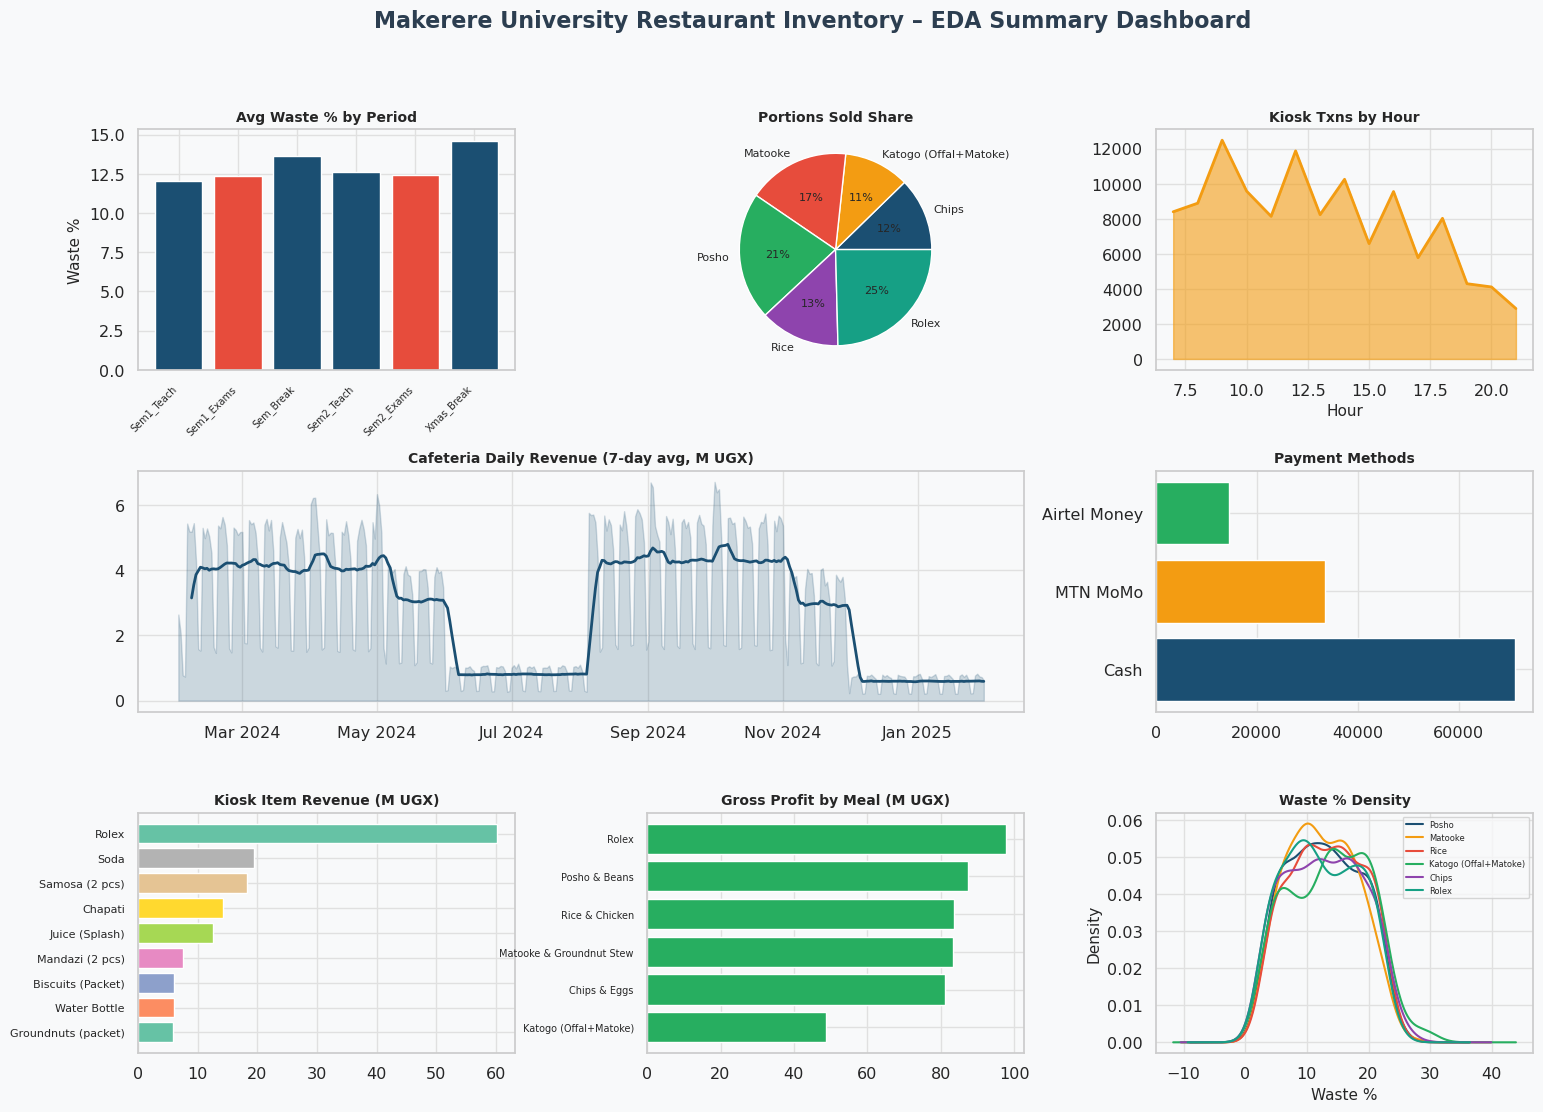

In [ ]:
#26
from matplotlib.gridspec import GridSpec


print("VIZ 25 – Summary Dashboard")
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#F8F9FA')
gs = GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.35)

fig.suptitle('Makerere University Restaurant Inventory – EDA Summary Dashboard',
             fontsize=16, fontweight='bold', color=MAKERERE_COLORS['dark'], y=0.98)

# A: Waste by period
ax1 = fig.add_subplot(gs[0, 0])
pw = cafe.groupby('Academic_Period', observed=True)['Waste_Pct'].mean()
c1 = [MAKERERE_COLORS['accent'] if 'Exam' in str(p) else MAKERERE_COLORS['primary'] for p in pw.index]
ax1.bar(range(len(pw)), pw.values, color=c1)
ax1.set_xticks(range(len(pw)))
ax1.set_xticklabels([str(p)[:10] for p in pw.index], rotation=45, ha='right', fontsize=7)
ax1.set_title('Avg Waste % by Period', fontweight='bold', fontsize=10)
ax1.set_ylabel('Waste %')

# B: Portions sold by meal (pie)
ax2 = fig.add_subplot(gs[0, 1])
ps = cafe.groupby('Meal')['Portions_Sold'].sum()
ax2.pie(ps.values, labels=[m.split('&')[0].strip() for m in ps.index],
        autopct='%1.0f%%', colors=MEAL_COLORS,
        textprops={'fontsize':8}, wedgeprops={'edgecolor':'white'})
ax2.set_title('Portions Sold Share', fontweight='bold', fontsize=10)

# C: Kiosk hourly
ax3 = fig.add_subplot(gs[0, 2])
h = kiosk.groupby('Hour').size()
ax3.fill_between(h.index, h.values, alpha=0.6, color=MAKERERE_COLORS['secondary'])
ax3.plot(h.index, h.values, color=MAKERERE_COLORS['secondary'], linewidth=2)
ax3.set_title('Kiosk Txns by Hour', fontweight='bold', fontsize=10)
ax3.set_xlabel('Hour')

# D: Revenue trend (cafe)
ax4 = fig.add_subplot(gs[1, :2])
dr = cafe.groupby('Date')['Revenue_UGX'].sum()
dr7 = dr.rolling(7).mean()
ax4.fill_between(dr.index, dr.values/1e6, alpha=0.2, color=MAKERERE_COLORS['primary'])
ax4.plot(dr.index, dr7.values/1e6, color=MAKERERE_COLORS['primary'], linewidth=2)
ax4.set_title('Cafeteria Daily Revenue (7-day avg, M UGX)', fontweight='bold', fontsize=10)
ax4.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))

# E: Payment split
ax5 = fig.add_subplot(gs[1, 2])
pm = kiosk['Payment_Method'].value_counts()
ax5.barh(pm.index, pm.values,
         color=[MAKERERE_COLORS['primary'], MAKERERE_COLORS['secondary'], MAKERERE_COLORS['green']])
ax5.set_title('Payment Methods', fontweight='bold', fontsize=10)

# F: Top items
ax6 = fig.add_subplot(gs[2, 0])
ti = kiosk.groupby('Item')['Total_Amount_UGX'].sum().sort_values(ascending=True)/1e6
ax6.barh(ti.index, ti.values, color=sns.color_palette('Set2', len(ti)))
ax6.set_title('Kiosk Item Revenue (M UGX)', fontweight='bold', fontsize=10)
ax6.tick_params(axis='y', labelsize=8)

# G: Gross profit by meal
ax7 = fig.add_subplot(gs[2, 1])
gp = cafe.groupby('Meal')['Gross_Profit_UGX'].sum().sort_values()/1e6
ax7.barh(gp.index, gp.values,
         color=[MAKERERE_COLORS['green'] if v>0 else MAKERERE_COLORS['accent'] for v in gp.values])
ax7.set_title('Gross Profit by Meal (M UGX)', fontweight='bold', fontsize=10)
ax7.tick_params(axis='y', labelsize=7)

# H: KDE waste
ax8 = fig.add_subplot(gs[2, 2])
for meal, color in zip(cafe['Meal'].unique(), MEAL_COLORS):
    cafe[cafe['Meal']==meal]['Waste_Pct'].plot.kde(ax=ax8, color=color, linewidth=1.5,
                                                    label=meal.split('&')[0].strip())
ax8.set_title('Waste % Density', fontweight='bold', fontsize=10)
ax8.set_xlabel('Waste %')
ax8.legend(fontsize=6)

plt.tight_layout()
plt.show()



VIZ 01 – Dataset Overview


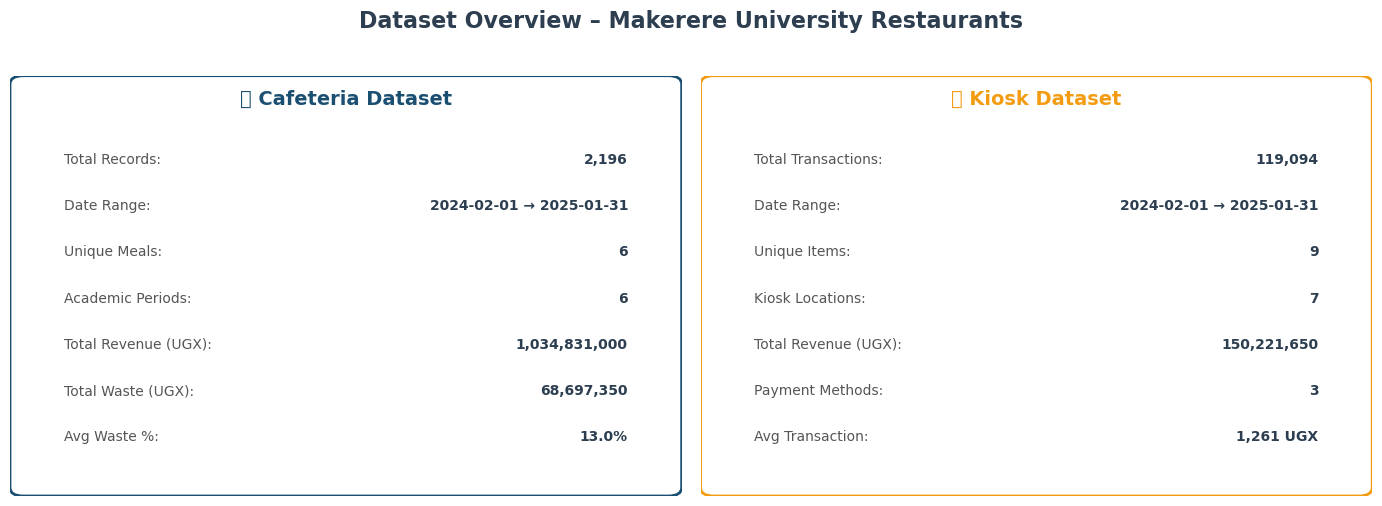

In [ ]:
#27
from matplotlib.patches import FancyBboxPatch

print("VIZ 01 – Dataset Overview")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Overview – Makerere University Restaurants', fontsize=16,
             fontweight='bold', color=MAKERERE_COLORS['dark'], y=1.01)

stats_cafe = {
    'Total Records':       f"{len(cafe):,}",
    'Date Range':          f"{cafe['Date'].min().date()} → {cafe['Date'].max().date()}",
    'Unique Meals':        str(cafe['Meal'].nunique()),
    'Academic Periods':    str(cafe['Academic_Period'].nunique()),
    'Total Revenue (UGX)': f"{cafe['Revenue_UGX'].sum():,.0f}",
    'Total Waste (UGX)':   f"{cafe['Waste_Cost_UGX'].sum():,.0f}",
    'Avg Waste %':         f"{cafe['Waste_Pct'].mean():.1f}%",
}
stats_kiosk = {
    'Total Transactions':  f"{len(kiosk):,}",
    'Date Range':          f"{kiosk['Date'].min().date()} → {kiosk['Date'].max().date()}",
    'Unique Items':        str(kiosk['Item'].nunique()),
    'Kiosk Locations':     str(kiosk['Kiosk_Name'].nunique()),
    'Total Revenue (UGX)': f"{kiosk['Total_Amount_UGX'].sum():,.0f}",
    'Payment Methods':     str(kiosk['Payment_Method'].nunique()),
    'Avg Transaction':     f"{kiosk['Total_Amount_UGX'].mean():,.0f} UGX",
}

for ax, stats, title, color in zip(
        axes,
        [stats_cafe, stats_kiosk],
        ['📋 Cafeteria Dataset', '🏪 Kiosk Dataset'],
        [MAKERERE_COLORS['primary'], MAKERERE_COLORS['secondary']]):
    ax.axis('off')
    ax.set_facecolor('#F0F4F8')
    ax.add_patch(FancyBboxPatch((0.02,0.02), 0.96, 0.96,
                                 boxstyle="round,pad=0.02",
                                 facecolor='white', edgecolor=color, linewidth=2,
                                 transform=ax.transAxes))
    ax.text(0.5, 0.93, title, transform=ax.transAxes,
            fontsize=14, fontweight='bold', ha='center', color=color)
    for i, (k, v) in enumerate(stats.items()):
        y = 0.80 - i * 0.11
        ax.text(0.08, y, f"{k}:", transform=ax.transAxes,
                fontsize=10, color='#555', va='center')
        ax.text(0.92, y, v, transform=ax.transAxes,
                fontsize=10, fontweight='bold', color=MAKERERE_COLORS['dark'],
                ha='right', va='center')

plt.tight_layout()
plt.show()